## EOO results
Author: Ru Feng and Jenny Empawi

### EOO Visualization 

#### Load libraries and data

In [2]:
# Load libraries
library(dplyr)
library(tidyverse)
library(data.table)
library(RColorBrewer)
library(scales)
library(cowplot)

In [3]:
# Load EOO results
eoo_res_all <- readRDS('/data/analysis_result/EOO/EOO_reshape_combined_result_withSNP_pip01_95cs_annotation_variant_level.updatedSep9th.RDS')

In [232]:
# Load meta
meta <- fread("/data/analysis_result/EOO/realease_data_readme.txt")  #FIXME
meta <- meta %>% mutate(context_mod = basename(Path) %>% gsub('.exported.toploci.bed.gz', '',.))

# Prepare enrichment data
enrichment_data <- eoo_res_all %>% mutate(Annotation = gsub('.to_hg38', '', Annotation)) %>% filter(!str_detect(Annotation,'hg19'))

enrichment_data <- enrichment_data %>%
  mutate(Annotation = ifelse(
    str_detect(Annotation, 'ENCFF038KTR|ENCFF015DGX|ENCFF370ANN'),
    str_replace(Annotation, '\\.bed$', '.bed.gz'),
    Annotation  # keep original if condition not met
  )) %>%
  distinct()

track_df <- fread("/data/analysis_result/EOO/categorized_annotation_tracks.csv") #uploaded to https://github.com/StatFunGen/xqtl-resources/tree/main/data/functional_annotations

enrichment_data <- merge(enrichment_data, track_df, by.x = 'Annotation', by.y = 'Track', all.x = T)%>% select(-Source) %>% distinct

# enrichment_data <- enrichment_data %>% mutate(Annotation = ifelse(str_detect(Annotation, 'ENCFF'),paste0(Category, "_", Annotation),Annotation))
enrichment_data <- enrichment_data %>% mutate(Annotation = paste0(Category, "|", Annotation))

# Reorder Annotation based on the order of Category
enrichment_data$Annotation <- factor(enrichment_data$Annotation, levels = unique(enrichment_data$Annotation[order(enrichment_data$Category)]))
enrichment_data %>% head

enrichment_data <- merge(enrichment_data, meta, by.x = 'study', by.y = 'context_mod', all.x = TRUE) %>% 
  mutate(`Data Type` = ifelse(is.na(`Data Type`), 'Other', `Data Type`),
         Method = ifelse(is.na(Method), 'Other', Method)) %>% 
  mutate(`Data Type` = ifelse(Method == 'single_context_finemapping' & str_detect(Modality, 'Inh|Exc|OPC|Oli|Mic|Ast'), 'snuc_eQTL', `Data Type` ),
         `Data Type` = ifelse(Method == 'multi_gene_finemapping', 'multi_gene', `Data Type` ),
         `Data Type` = ifelse(method == 'multicontext', 'multi_context', `Data Type` ),
         `Data Type` = ifelse(str_detect(study, 'haQTL|mQTL'), 'Epi', `Data Type` )) %>% filter(!str_detect(Annotation, "ENCFF"))

,Annotation,OR,OR_SE,OR_log2,OR_SE_log2,Enrichment,Enrichment_SE,Enrichment_log2,Enrichment_SE_log2,study,⋯,annotation,annotation_sets,Enrichment_Z_score,Enrichment_P_value,Z_or,P_or,Assay,Data_Category,Cell_Type,Category
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,⋯,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,Transcription_Factor_Binding|1_GATA2-Interval-Track,1.809502,0.11650544,0.8555927,0.09286834,1.783705,0.11105414,0.8347443,0.08981472,Oli_DeJager_eQTL_multicontext,⋯,NA,NA,16.061585,4.742789e-58,NA,NA,,,,Transcription_Factor_Binding
2,Transcription_Factor_Binding|1_GATA2-Interval-Track,2.347758,0.46736472,1.2312838,0.29880894,2.296091,0.43987546,1.1978521,0.28743723,Mic_Kellis_eQTL_multicontext,⋯,NA,NA,5.219866,1.790524e-07,NA,NA,,,,Transcription_Factor_Binding
3,Transcription_Factor_Binding|1_GATA2-Interval-Track,1.707677,0.09218601,0.7720348,0.07769254,1.686189,0.08812173,0.7536727,0.07522796,Ast_DeJager_eQTL_multicontext,⋯,NA,NA,19.134770,1.296498e-81,NA,NA,,,,Transcription_Factor_Binding
4,Transcription_Factor_Binding|1_GATA2-Interval-Track,1.600990,0.07593498,0.6789646,0.06826243,1.582428,0.07270452,0.6620679,0.06613290,DLPFC_DeJager_eQTL_multicontext,⋯,NA,NA,21.765198,4.959513e-105,NA,NA,,,,Transcription_Factor_Binding
5,Transcription_Factor_Binding|1_GATA2-Interval-Track,1.826027,0.14506736,0.8687084,0.11530654,1.800184,0.13848111,0.8479395,0.11164329,OPC_DeJager_eQTL_multicontext,⋯,NA,NA,12.999492,1.231594e-38,NA,NA,,,,Transcription_Factor_Binding
6,Transcription_Factor_Binding|1_GATA2-Interval-Track,1.586308,0.14484476,0.6656734,0.13222318,1.570301,0.13950901,0.6507685,0.12866153,DLPFC_Bennett_pQTL_multicontext,⋯,NA,NA,11.255910,2.165796e-29,NA,NA,,,,Transcription_Factor_Binding


In [234]:
enrichment_data <- enrichment_data  %>% mutate(Cohort = ifelse(str_detect(study, 'MSBB'), 'MSBB', 
                                            ifelse(str_detect(study, 'Knight|KNIGHT'), 'KNIGHT',
                                                  ifelse(str_detect(study, 'STARNET'), 'STARNET',
                                                        ifelse(str_detect(study, 'MIGA|MiGA'), 'MIGA', 'ROSMAP')))))

In [235]:
  options(repr.plot.width = 24, repr.plot.height = 20)


In [289]:
library(pheatmap)
library(dplyr)
library(tidyr)
library(stringr)
library(RColorBrewer)

# ====== Step 1. 数据整理 ======
plot_df_raw <- enrichment_data %>%
  filter(Enrichment_P_value < 0.05, method != 'trans', Category != 'Miscellaneous', study != 'xqtl_only_colocboost') %>%
  mutate(
    # 生成 Super_category
    Super_category = case_when(
      Category %in% c(
        "CellType_Neuron", "CellType_Astrocyte", "CellType_Microglia_Myeloid",
        "CellType_Oligodendrocyte", "CellType_Progenitor",
        "CellType_Neuroblastoma", "CellType_OtherNonNeural",
        "CellType_Vascular"
      ) ~ "CellType_specific",
      Category %in% c("eQTL", "sQTL") ~ "Molecular_QTL",
      Category %in% c(
        "Epigenetic_Histone_Modifications",
        "Chromatin_Accessibility",
        "Chromatin_Interaction_Loops",
        "Enhancer_SuperEnhancer",
        "Promoter",
        "Transcription_Factor_Binding",
        "Transcription_Factor_Footprints"
      ) ~ "Epigenetic_Regulation",
      Category %in% c("Genomic_Conservation") ~ "Conservation",
      Category %in% c("Miscellaneous", "Other_Functional_Annotations") ~ "Other",
      TRUE ~ "Other"
    ),
    # 生成 QTL_type（根据 study 名称模式，可按需修改）
    QTL_type = case_when(
      str_detect(study, 'eQTL|Metabrain|AC|PCC|DLPFC') & !str_detect(study, 'sQTL|pQTL|haQTL|mQTL') ~ "eQTL",
      str_detect(study, 'Oli|OPC|Mic|Ast|Exc|Inh|monocyte') ~ "snuc-eQTL",
      str_detect(study, 'sQTL') ~ "sQTL",
      # str_detect(study, 'colocboost') ~ "multi-gene",
      str_detect(study, 'pQTL') ~ "pQTL",
      str_detect(study, 'haQTL') ~ "haQTL",
      str_detect(study, 'mQTL') ~ "mQTL",
      str_detect(study, 'metabolome') ~ "metaQTL",
      TRUE ~ "Other"
    )
  ) 
plot_df <- plot_df_raw %>%
  group_by(Method, Cohort, QTL_type, Category, Super_category, study) %>%
  summarise(mean_log2 = mean(Enrichment_log2[is.finite(Enrichment_log2)], na.rm = TRUE), .groups = "drop")
# ====== Step 2. 转宽矩阵 ======
mat <- plot_df %>%
  select(Category, study, mean_log2) %>%
  distinct() %>%
  pivot_wider(names_from = study, values_from = mean_log2) %>%
  column_to_rownames("Category") %>%
  as.matrix()

# ====== Step 3. 修复 Inf / NA ======
finite_vals <- mat[is.finite(mat)]
min_val <- if (length(finite_vals) > 0) min(finite_vals) else 0
mat[is.infinite(mat)] <- NA    # 让 -Inf 用 NA 显示灰色
mat[is.nan(mat)] <- NA

# ====== Step 4. 按 Super_category 聚类排序 ======
category_info <- plot_df %>% distinct(Category, Super_category)
category_order <- category_info %>% arrange(Super_category, Category) %>% pull(Category)
mat <- mat[intersect(category_order, rownames(mat)), , drop = FALSE]

# ====== Step 5. annotation 数据 ======
anno_col <- plot_df %>%
  distinct(study, Method, Cohort, QTL_type) %>%
  column_to_rownames("study")

anno_row <- category_info %>% column_to_rownames("Category")
names(ann_colors)[names(ann_colors) == "Super_category"] <- ""
# ====== Step 6. annotation 颜色 ======
ann_colors <- list(
  Method = setNames(brewer.pal(8, "Set3")[seq_along(unique(anno_col$Method))],
                    unique(anno_col$Method)),
  Cohort = setNames(brewer.pal(8, "Set2")[seq_along(unique(anno_col$Cohort))],
                    unique(anno_col$Cohort)),
  QTL_type = setNames(brewer.pal(8, "Pastel1")[seq_along(unique(anno_col$QTL_type))],
                      unique(anno_col$QTL_type)),
  Super_category = setNames(brewer.pal(8, "Pastel1")[seq_along(unique(anno_row$Super_category))],
                            unique(anno_row$Super_category))
)
# p <- pheatmap(
#   mat,
#   color = colorRampPalette(rev(brewer.pal(11, "RdYlBu")))(200),
#   na_col = "grey80",
#   annotation_col = anno_col,
#   annotation_row = anno_row,
#   annotation_colors = ann_colors,
#   cluster_rows = FALSE,
#   cluster_cols = FALSE,
#   border_color = NA,
#   show_colnames = FALSE,
#   show_rownames = TRUE,
#   fontsize = 14,
#   fontsize_row = 13,
#   fontsize_col = 13,
#   angle_col = 45 
# )



In [ ]:
library(dplyr)
library(pheatmap)
library(tibble)
library(grid)
library(RColorBrewer)

library(dplyr)
library(pheatmap)
library(tibble)
library(grid)
library(RColorBrewer)

# ===== 手动定义顺序 =====
sc_levels <- plot_df %>%
  distinct(Super_category) %>%
  pull(Super_category)
sc_levels <- c("Molecular_QTL", setdiff(sc_levels, "Molecular_QTL"))

method_levels <- c("univariate", "epi_susie", "multicontext", "multigene", "coloc")

# ===== 行信息 =====
row_info <- plot_df %>%
  distinct(Category, Super_category, Method) %>%
  mutate(
    Super_category = factor(Super_category, levels = sc_levels),
    Method = factor(Method, levels = method_levels)
  ) %>%
  arrange(Super_category, Method)

row_order <- c()
for (sc in levels(row_info$Super_category)) {
  for (m in levels(row_info$Method)) {
    cats <- row_info %>%
      filter(Super_category == sc, Method == m) %>%
      pull(Category)
    sub_mat <- mat[intersect(cats, rownames(mat)), , drop = FALSE]
    if (nrow(sub_mat) > 1) {
      hc <- hclust(dist(sub_mat))
      row_order <- c(row_order, rownames(sub_mat)[hc$order])
    } else {
      row_order <- c(row_order, cats)
    }
  }
}
row_order <- unique(row_order)
mat_ord <- mat[intersect(row_order, rownames(mat)), , drop = FALSE]

# ===== 列聚类 =====
col_info <- anno_col %>%
  rownames_to_column("study") %>%
  mutate(Method = factor(Method, levels = method_levels)) %>%
  arrange(Method)

col_order <- c()
for (m in levels(col_info$Method)) {
  cols <- col_info %>% filter(Method == m) %>% pull(study)
  sub_mat <- t(mat_ord[, intersect(cols, colnames(mat_ord)), drop = FALSE])
  if (nrow(sub_mat) > 1) {
    hc_col <- hclust(dist(sub_mat))
    col_order <- c(col_order, rownames(sub_mat)[hc_col$order])
  } else {
    col_order <- c(col_order, cols)
  }
}
col_order <- unique(col_order)
mat_ord <- mat_ord[, intersect(col_order, colnames(mat_ord)), drop = FALSE]

# ===== 加入 Cohort 颜色 =====
# Cohort colors
QTL_colors <- c(
  "eQTL"  = "#4C72B0",
  "sQTL"    = "#55A868",
  "snuc-eQTL"    = "#C44E52",
  "pQTL" = "#8172B2",
  "mQTL"  = "#CCB974",
    "haQTL" = "#D6853B" 
    
)

ann_colors$QTL_type <- QTL_colors

agg_record_417509287 
                   2

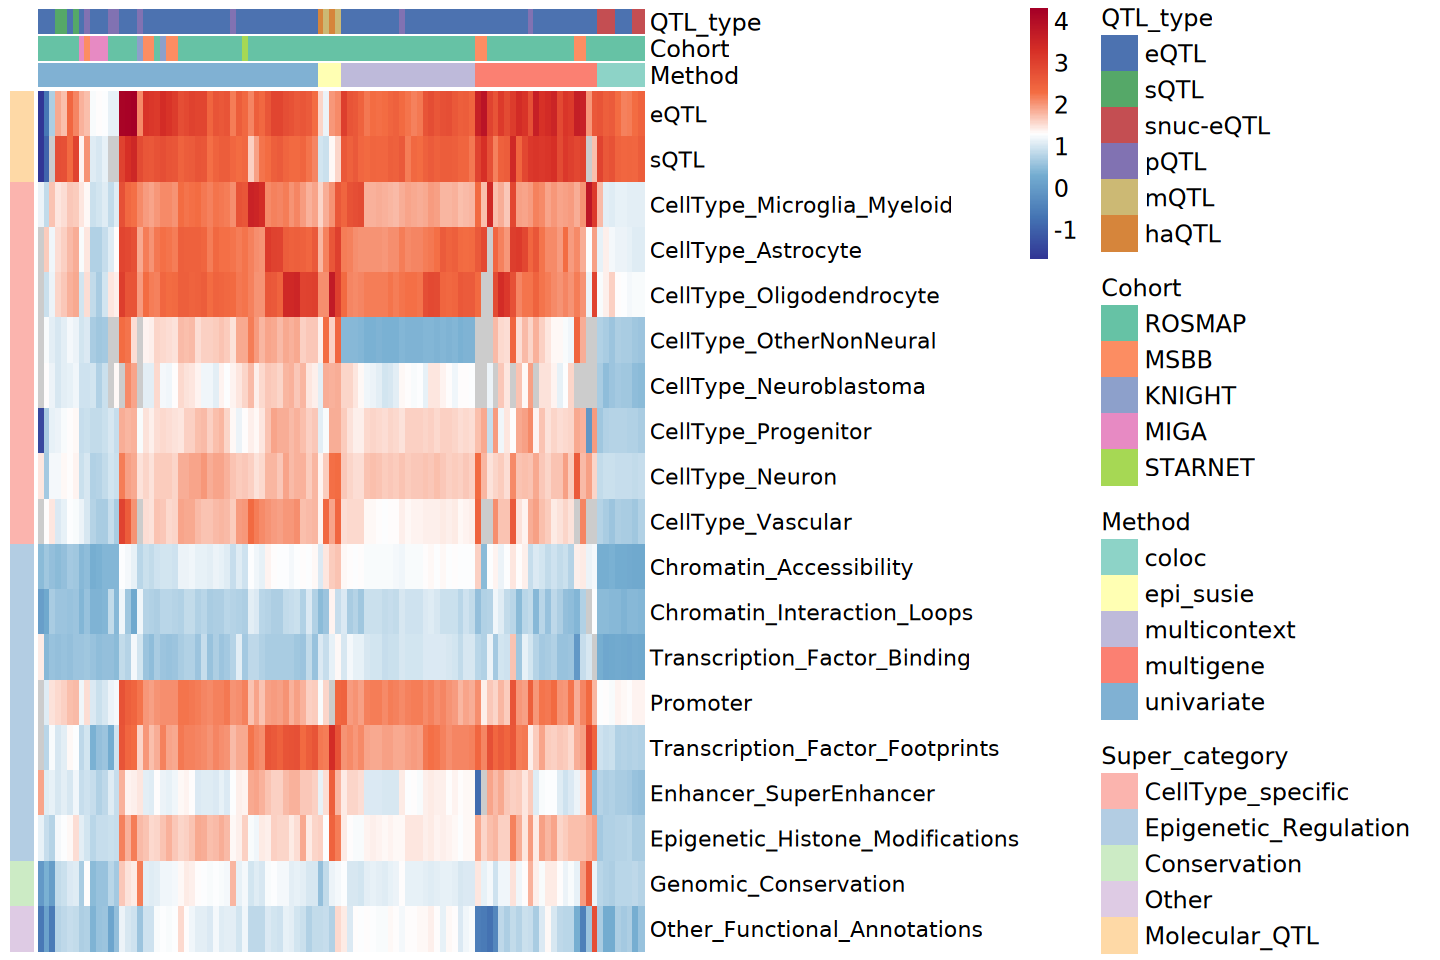

In [340]:
p <- pheatmap(
  mat_ord,
  # color = colorRampPalette(rev(brewer.pal(11, "RdYlBu")))(200),
    color = colorRampPalette(c("#313695", "#4575B4", "#74ADD1", 
                           "white",
                           "#F46D43", "#D73027", "#A50026"))(200),
  na_col = "grey80",
  annotation_col = anno_col[colnames(mat_ord), , drop = FALSE],
  annotation_row = anno_row[rownames(mat_ord), , drop = FALSE],
  annotation_colors = ann_colors,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  border_color = NA,
  show_colnames = FALSE,
  show_rownames = TRUE,
  fontsize = 14,
  fontsize_row = 13,
  fontsize_col = 13,
  angle_col = 45,
  legend = TRUE,
  legend_breaks = NULL,
  legend_labels = NULL,
  legend_cex = 0.5,
  annotation_legend = TRUE,
  annotation_legend_side = "right",
  annotation_names_col = TRUE,
  annotation_names_row = FALSE,
  fontsize_legend = 9,
  annotation_names_gp = grid::gpar(fontsize = 9)
)

pdf("Figure1C.enrichment_heatmap.pdf", width = 12, height = 6)
grid.newpage()
grid.draw(p$gtable)
dev.off()

Warning message in RColorBrewer::brewer.pal(n, pal):
“n too large, allowed maximum for palette Set3 is 12
Returning the palette you asked for with that many colors
”


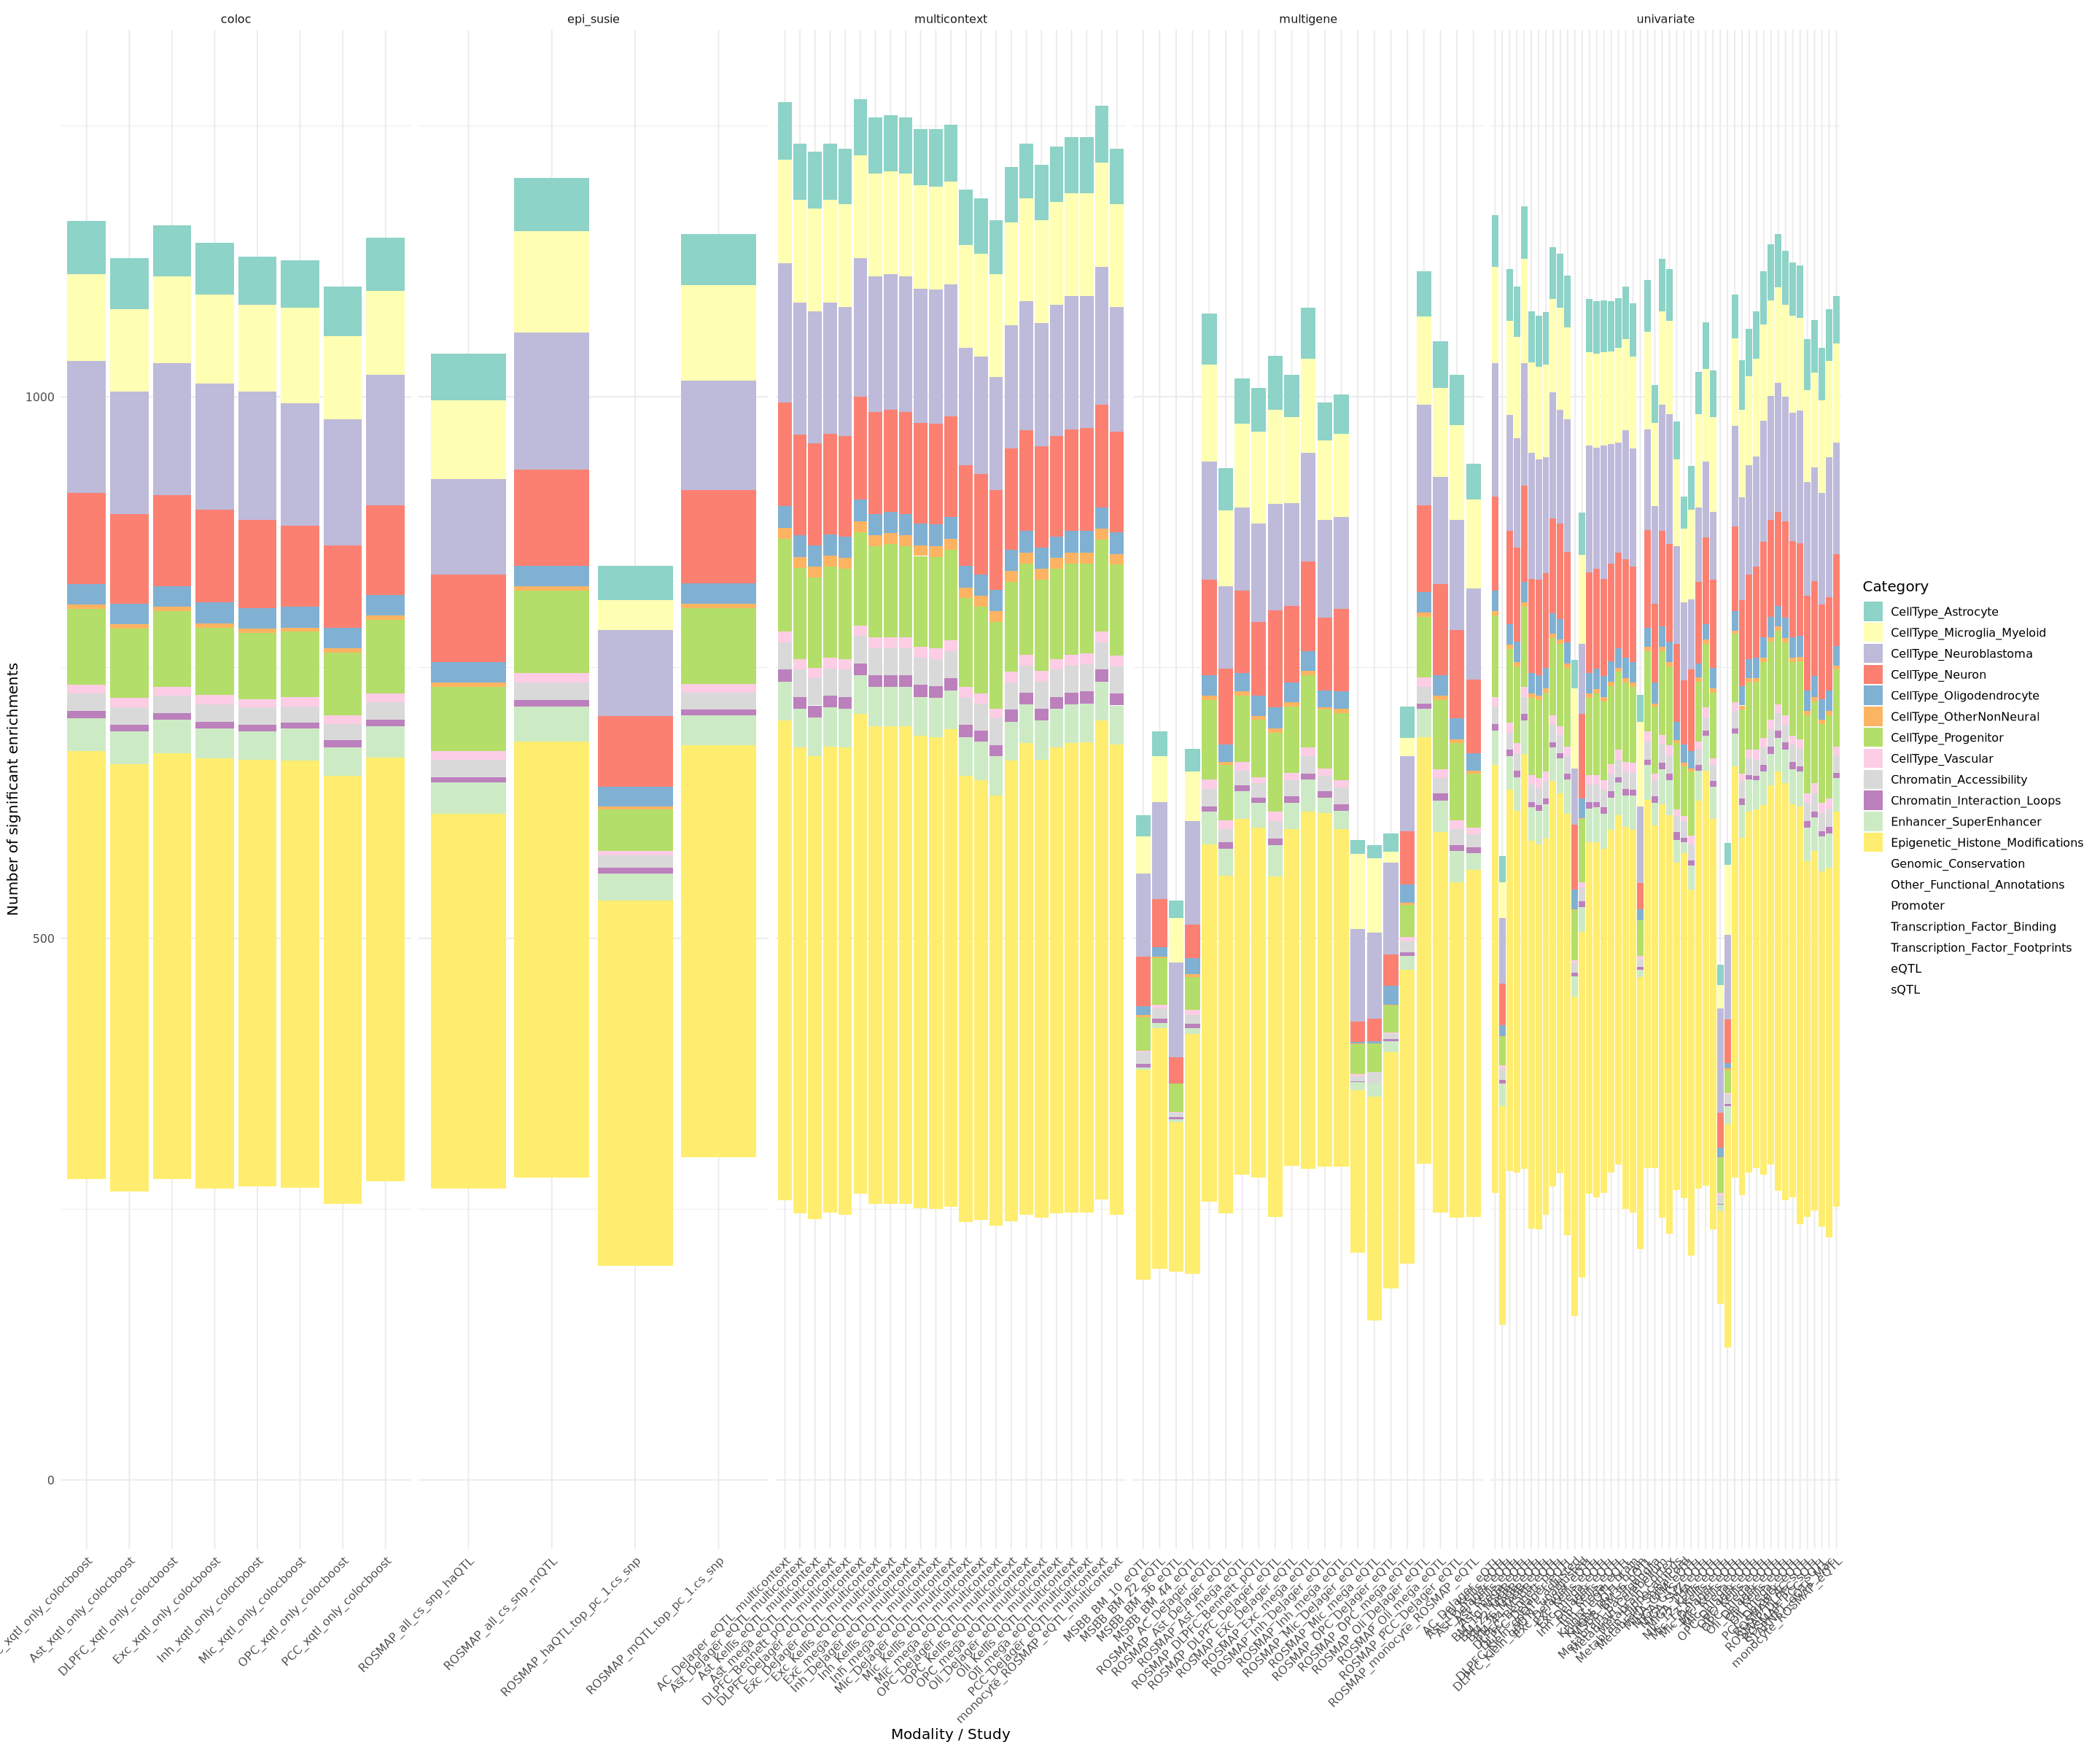

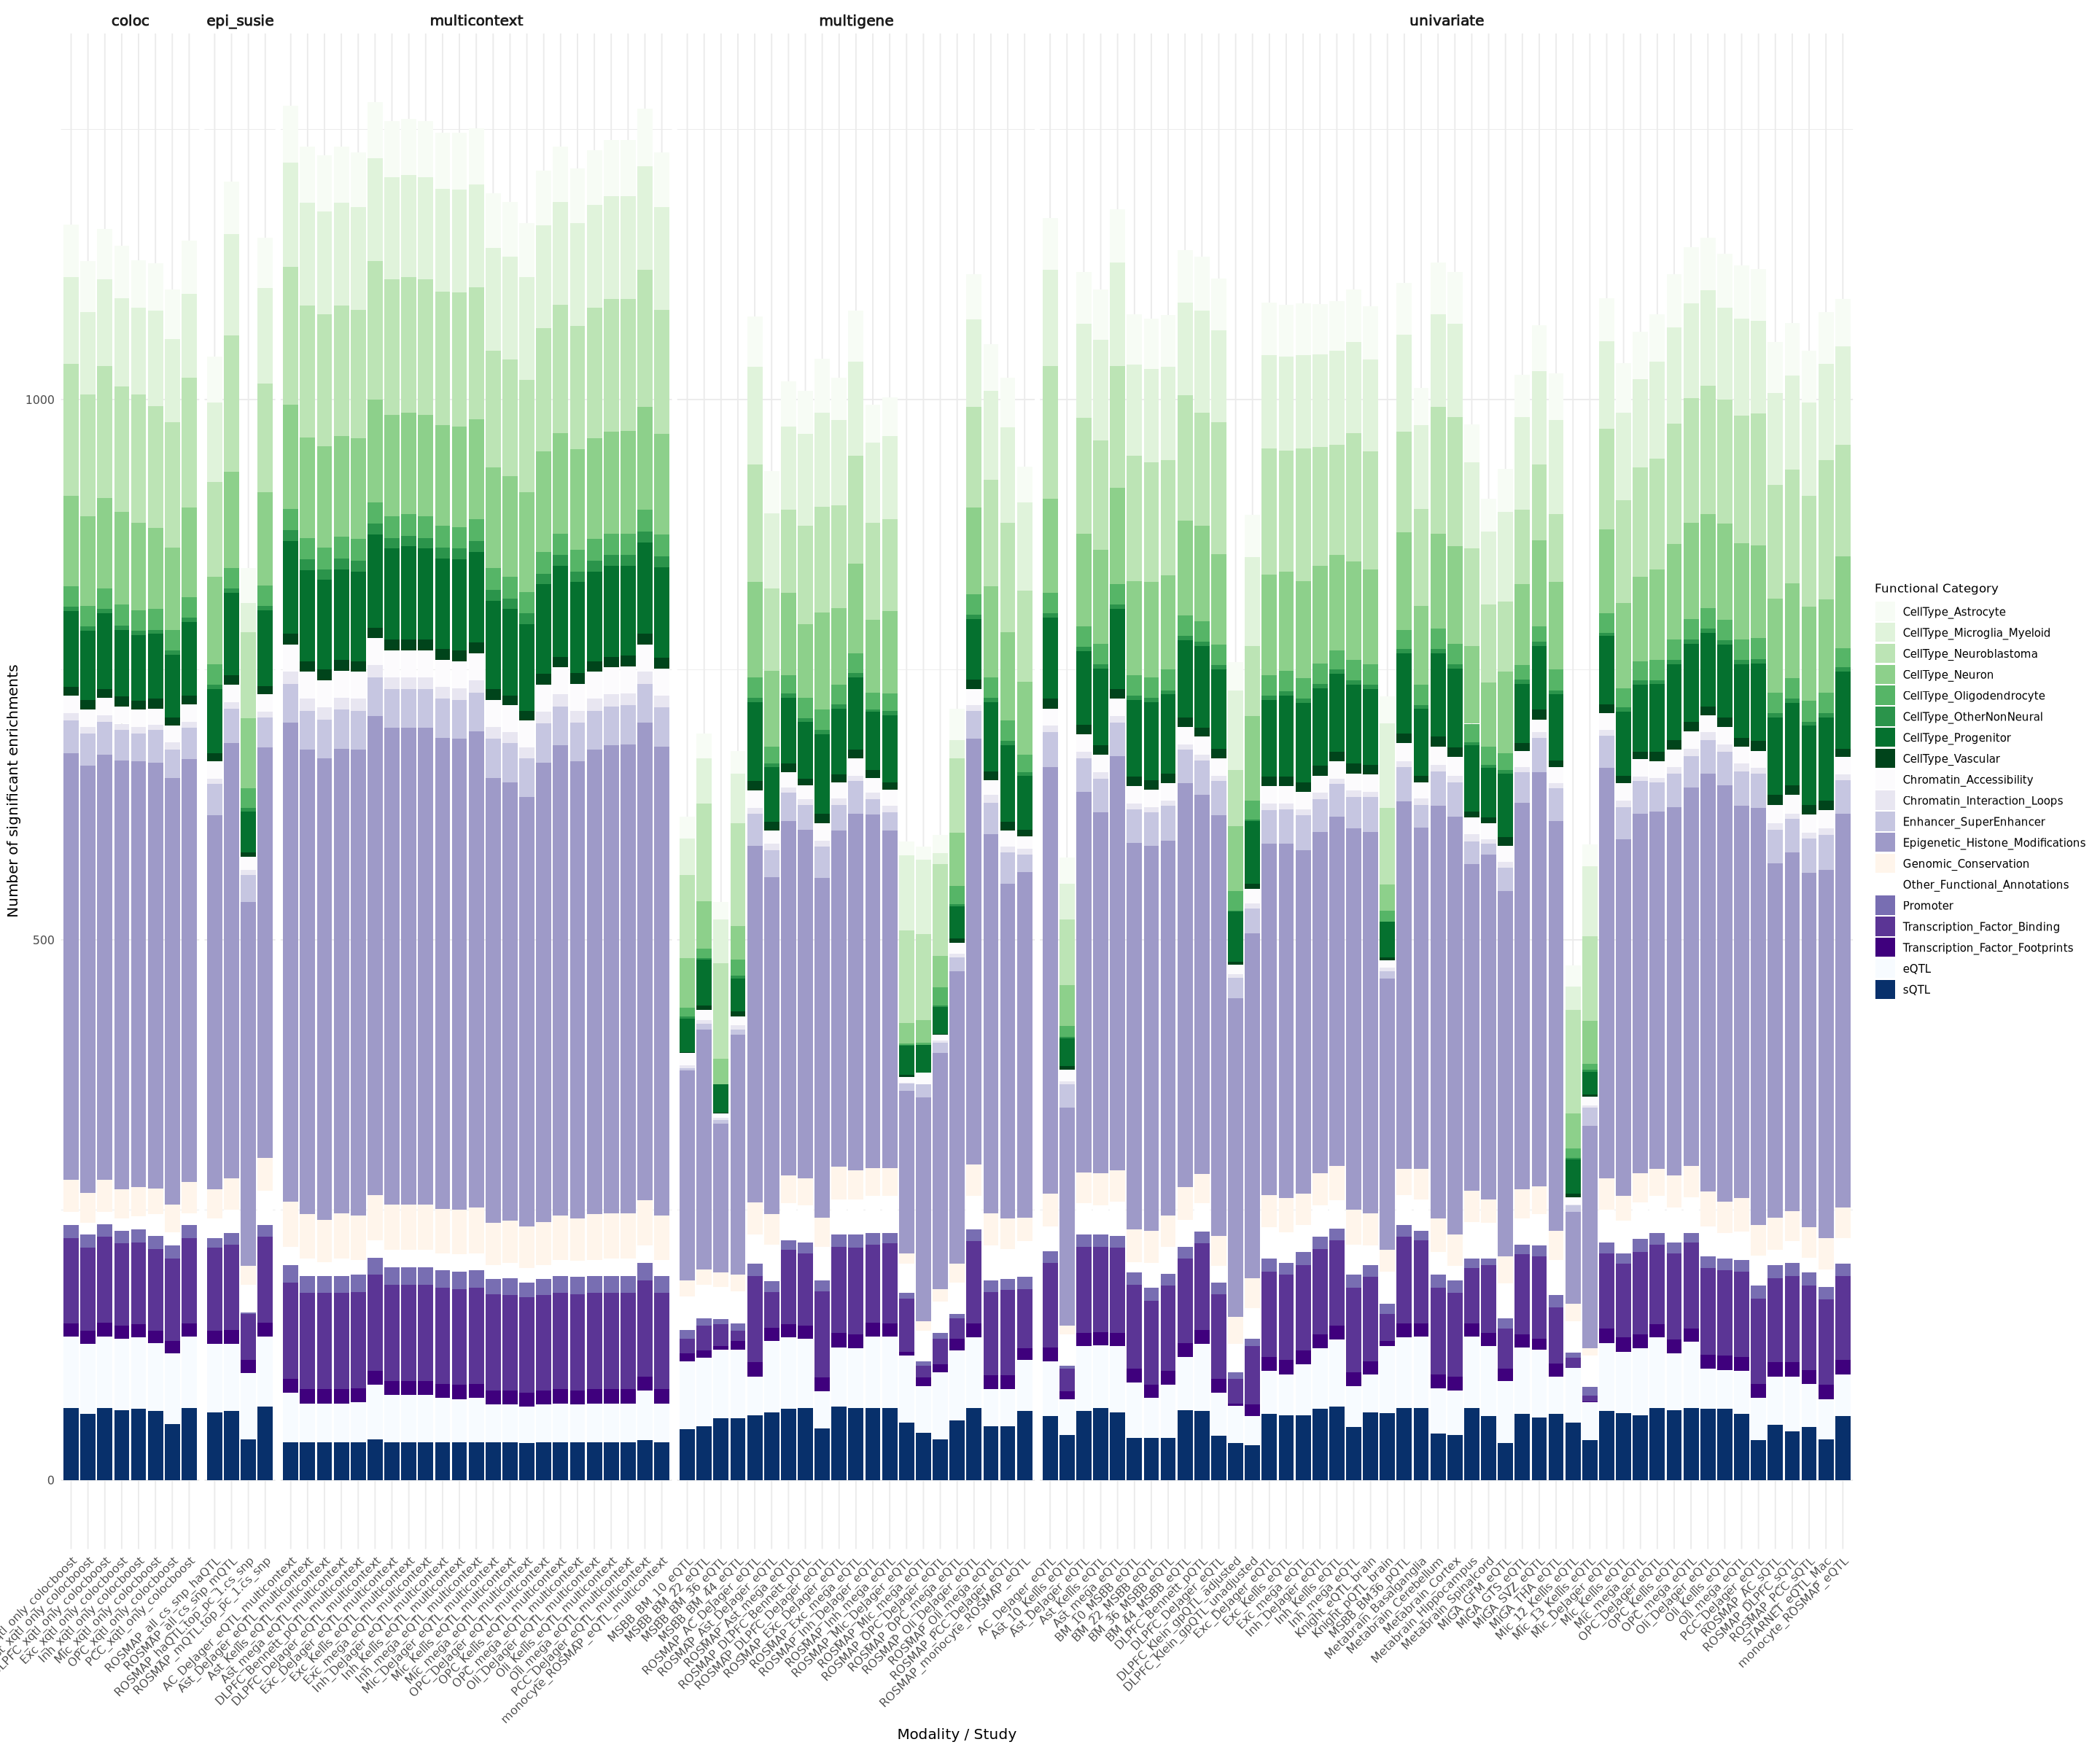

In [182]:
# # plot_df <- enrichment_data %>%
# #   filter(Enrichment_P_value < 0.05, method != 'trans', Category != 'Miscellaneous', study != 'xqtl_only_colocboost') %>%
# #   count(study, Category)

# ggplot(plot_df_raw %>% count(study, Category, Method), aes(x = study, y = n, fill = Category)) +
#   geom_bar(stat = "identity", position = "stack") +
#   facet_grid(~ Method, scale = 'free') + 
#   scale_fill_brewer(palette = "Set3") +
#   theme_minimal(base_size = 12) +
#   theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
#   labs(x = "Modality / Study", y = "Number of significant enrichments")
# # 确保 Category 和 Super_category 对应表
# cat_info <- plot_df_raw %>%
#   distinct(Category, Super_category)

# # 为 Super_category 分配主色系
# super_palettes <- c(
#   "Molecular_QTL" = "Blues",
#   "Epigenetic_Regulation" = "Purples",
#   "CellType_specific" = "Greens",
#   "Conservation" = "Oranges",
#   "Other" = "Greys"
# )

# # 每个 Super_category 内生成独立色板（修正版）
# cat_colors <- cat_info %>%
#   group_by(Super_category) %>%
#   mutate(
#     color = {
#       pal_name <- unique(Super_category)[1]  # ⬅️ 取单个值
#       base_pal <- brewer.pal(9, super_palettes[[pal_name]])
#       colorRampPalette(base_pal)(n())[rank(Category)]
#     }
#   ) %>%
#   ungroup()

# # 构建最终 Category→颜色映射表
# cat_color_map <- setNames(cat_colors$color, cat_colors$Category)

# # 绘图
# ggplot(plot_df_raw %>% count(study, Category, Method),
#        aes(x = study, y = n, fill = Category)) +
#   geom_bar(stat = "identity", position = "stack") +
#   ggforce::facet_row(~ Method, scales = "free_x", space = "free") +  # 一行、宽度自适应
#   scale_fill_manual(values = cat_color_map) +
#   theme_minimal(base_size = 12) +
#   theme(
#     axis.text.x = element_text(angle = 45, hjust = 1),
#     strip.text = element_text(size = 12, face = "bold"),
#     panel.spacing.x = unit(0.3, "lines"),
#     legend.text = element_text(size = 9),
#     legend.title = element_text(size = 10)
#   ) +
#   labs(
#     x = "Modality / Study",
#     y = "Number of significant enrichments",
#     fill = "Functional Category"
#   )

In [9]:
options(repr.plot.width = 20, repr.plot.height =20)


`summarise()` has grouped output by 'Category'. You can override using the
`.groups` argument.


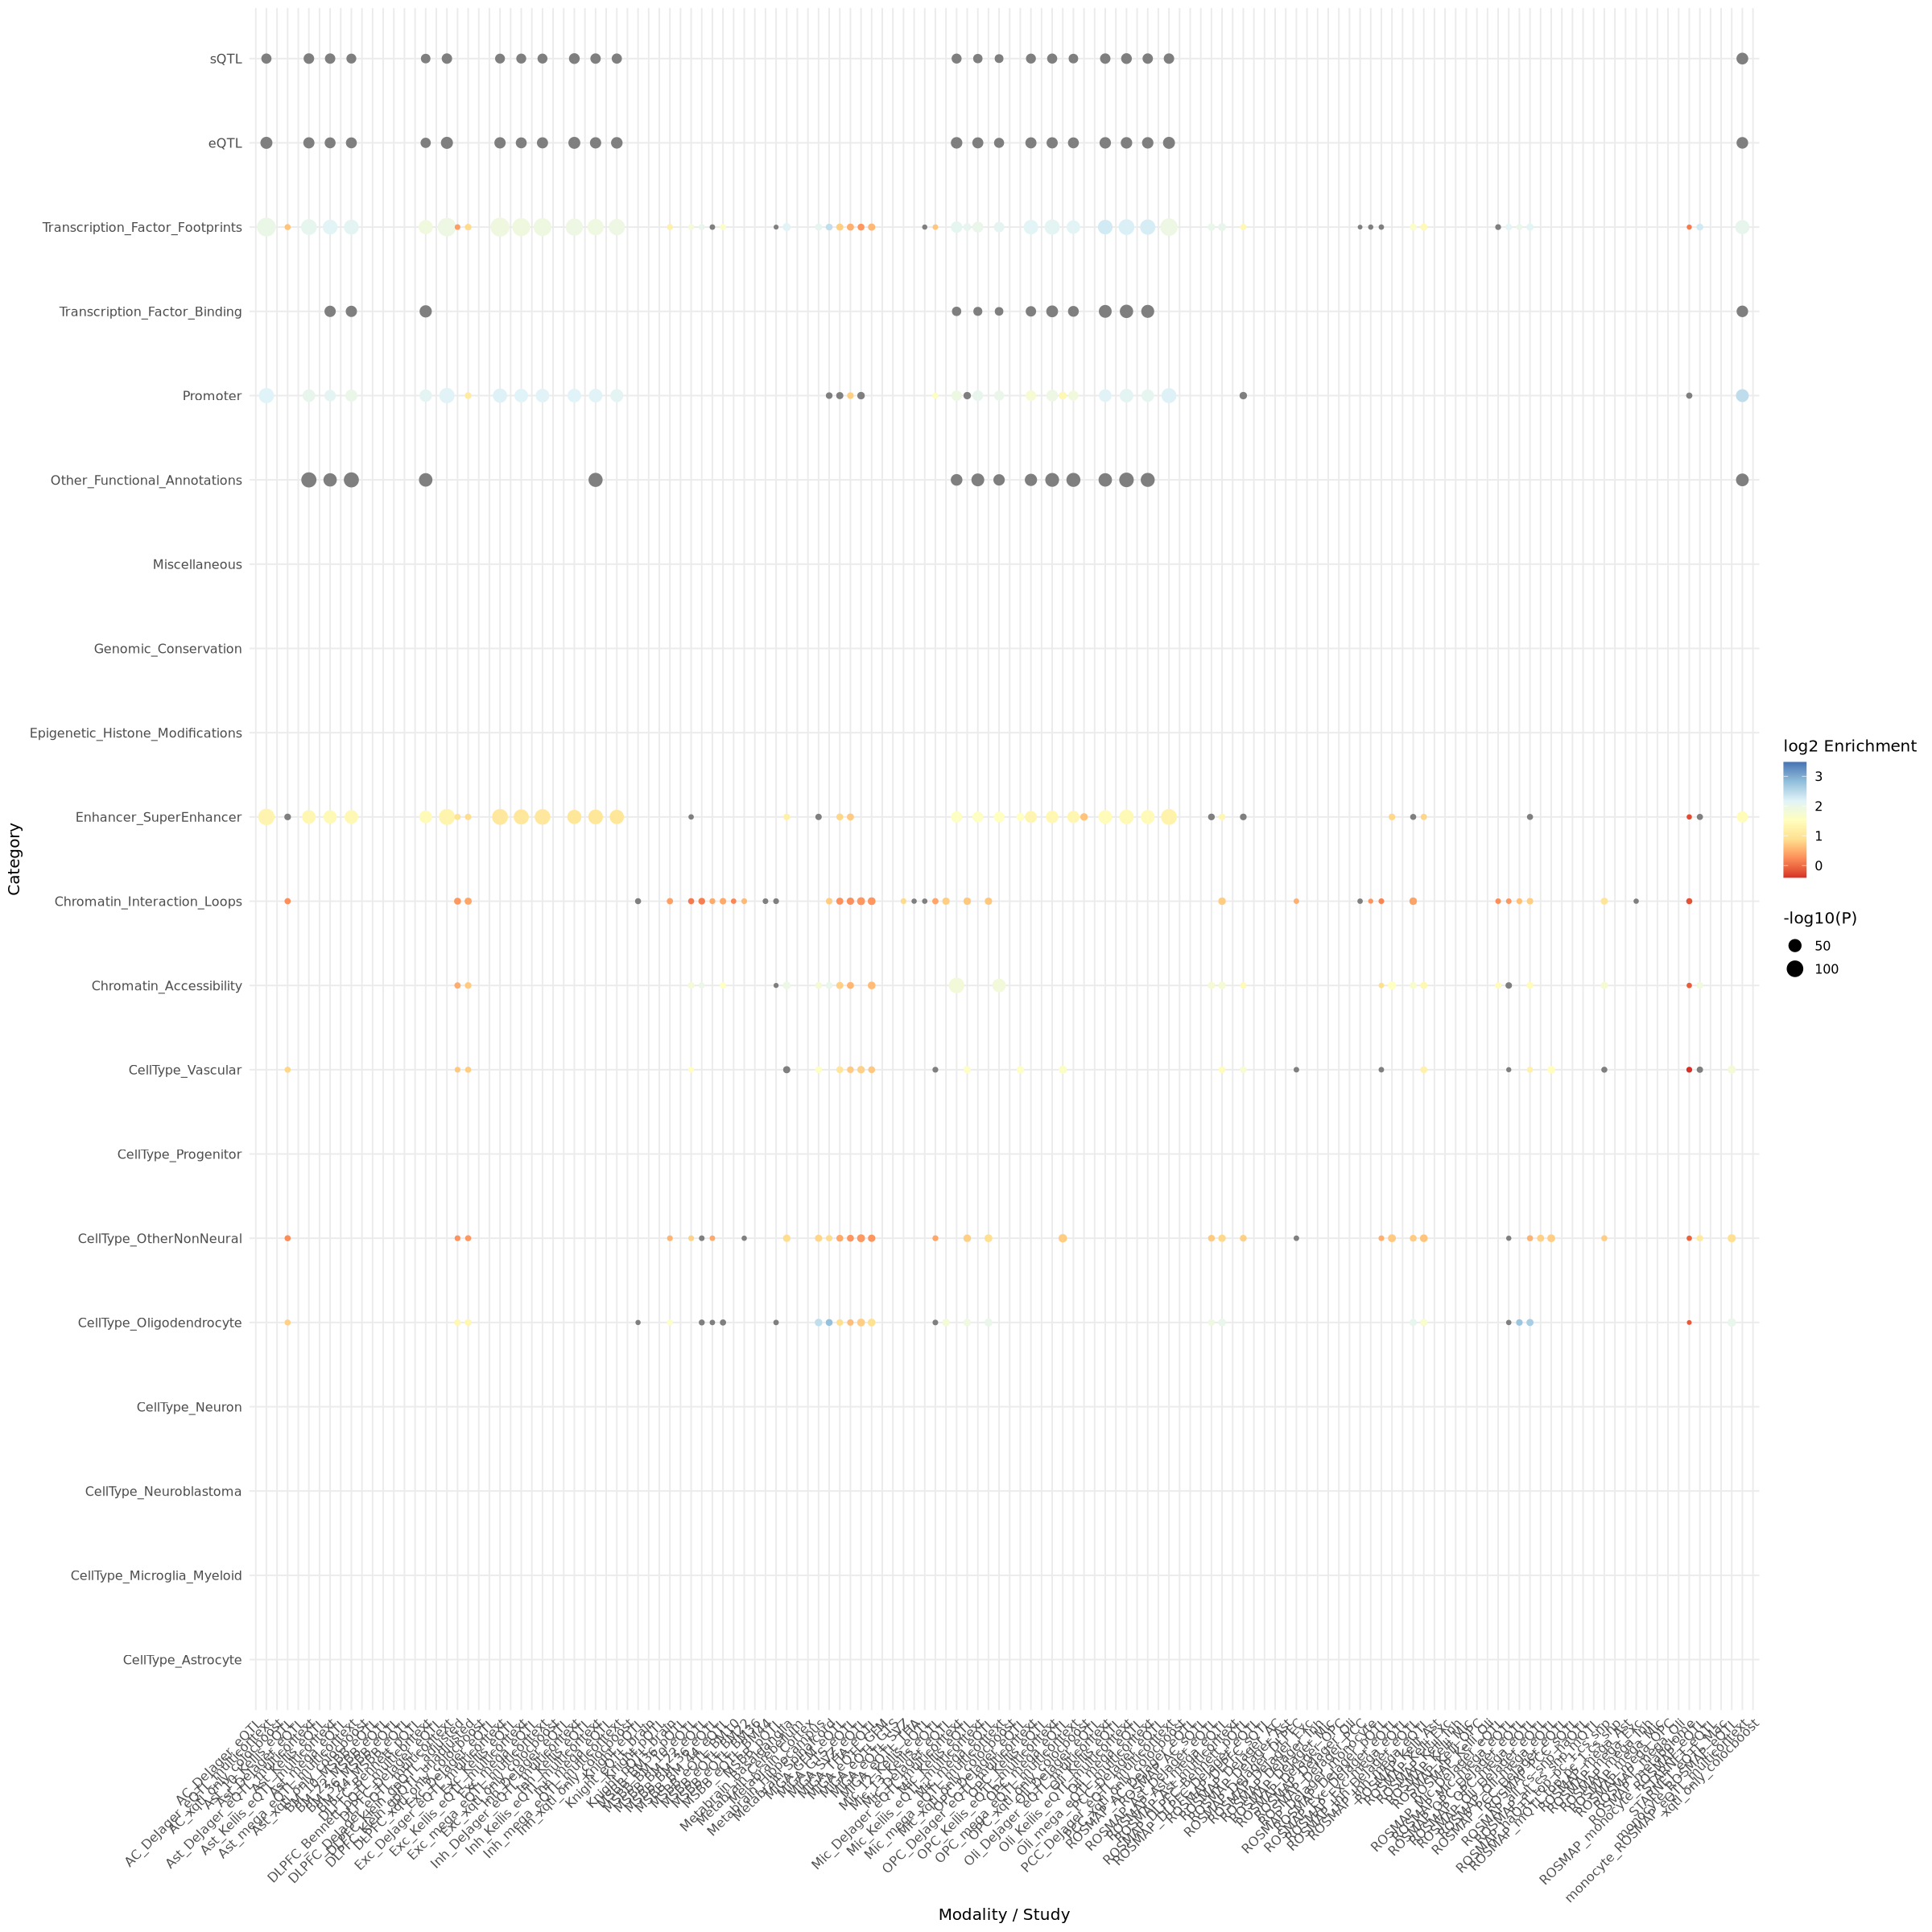

In [11]:
plot_df <- enrichment_data %>%
  mutate(P_log10 = -log10(Enrichment_P_value)) %>%
  group_by(Category, study) %>%
  summarise(mean_log2 = mean(Enrichment_log2, na.rm = TRUE),
            mean_P = mean(P_log10, na.rm = TRUE)) %>%
  ungroup()

ggplot(plot_df, aes(x = study, y = Category)) +
  geom_point(aes(size = mean_P, color = mean_log2)) +
  scale_color_distiller(palette = "RdYlBu", direction = 1) +
  scale_size_continuous(name = "-log10(P)") +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(x = "Modality / Study", y = "Category", color = "log2 Enrichment")

Warning message in RColorBrewer::brewer.pal(n, pal):
“n too large, allowed maximum for palette Set3 is 12
Returning the palette you asked for with that many colors
”


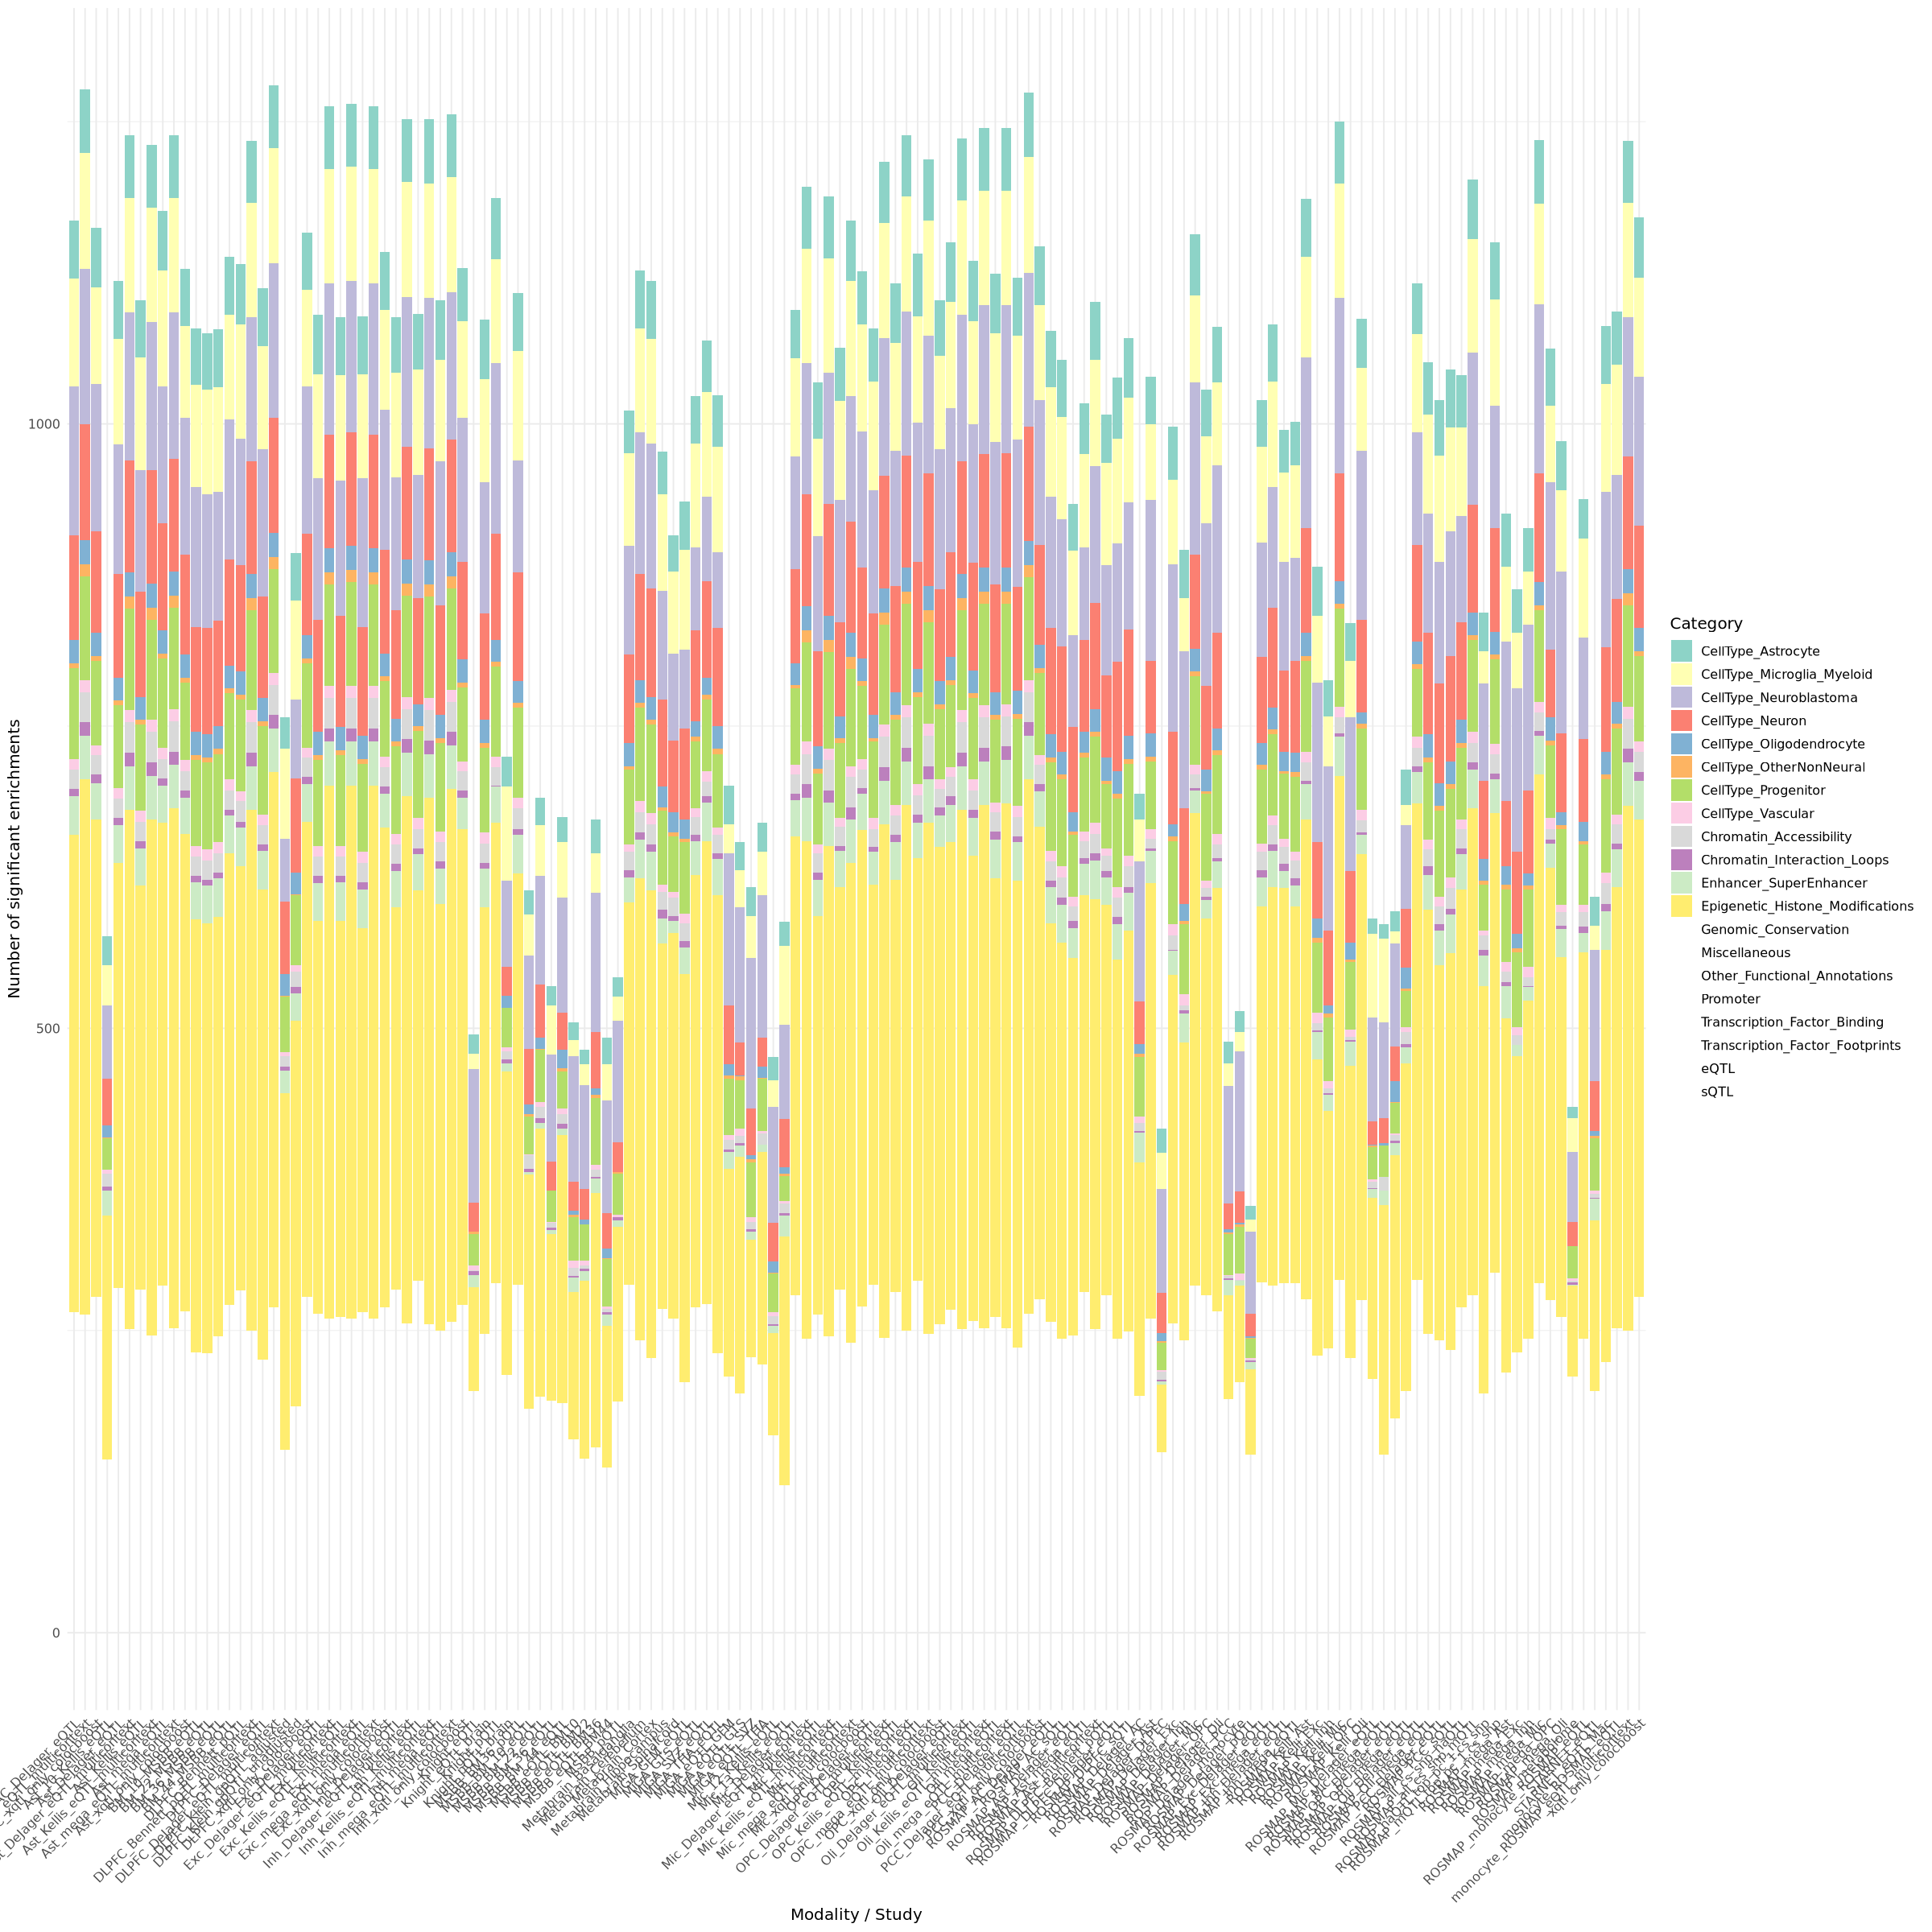

In [12]:
plot_df <- enrichment_data %>%
  filter(Enrichment_P_value < 0.05) %>%
  count(study, Category)

ggplot(plot_df, aes(x = study, y = n, fill = Category)) +
  geom_bar(stat = "identity", position = "stack") +
  scale_fill_brewer(palette = "Set3") +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(x = "Modality / Study", y = "Number of significant enrichments")

### Test between methods ####

#### Test data

To identify annotations with significantly different enrichment values between the single-context (eQTL) and multi-gene (adj_eQTL) datasets, a statistical test was performed on annotations with significant enrichment (Enrichment_P_value < 0.05) in at least one dataset. The datasets were merged by matching annotations, retaining only those significant in either dataset, and rows with missing or infinite values were excluded. Due to the non-normal distribution of enrichment differences (confirmed by a Shapiro-Wilk p-value of 5.623531e-60 in one context), a Z-score test was applied to each paired annotation, calculating the difference (Enrichment_adj - Enrichment_pqtl) divided by the combined standard error. P-values were derived from Z-scores and adjusted for multiple testing using the False Discovery Rate (FDR) method. Annotations with FDR-adjusted p-values < 0.05 were considered significantly different, indicating systematic differences in enrichment between the single-context and multi-gene datasets for those annotations.

#### Multi gene to single context #####

In [238]:
enrichment_data_meta = enrichment_data

In [239]:
bulk_eQTL <- enrichment_data_meta %>% filter(`Data Type` == 'eQTL')
snuc_eQTL <- enrichment_data_meta %>% filter(`Data Type` == 'snuc_eQTL')
eQTL_raw <- rbind(bulk_eQTL, snuc_eQTL)
multi_gene_eQTL <- enrichment_data_meta %>% filter(`Data Type` == 'multi_gene')

# build a modalities dict to combine single context and multi gene results 
modality_dict <- c(
  # MSBB
  "BM_10_MSBB_eQTL" = "MSBB_BM_10_eQTL",
  "BM_22_MSBB_eQTL" = "MSBB_BM_22_eQTL",
  "BM_36_MSBB_eQTL" = "MSBB_BM_36_eQTL",
  "BM_44_MSBB_eQTL" = "MSBB_BM_44_eQTL",
  
  # DeJager and mega (ROSMAP)
  "AC_DeJager_eQTL" = "ROSMAP_AC_DeJager_eQTL",
  "Ast_DeJager_eQTL" = "ROSMAP_Ast_DeJager_eQTL",
  "Ast_mega_eQTL" = "ROSMAP_Ast_mega_eQTL",
  "DLPFC_DeJager_eQTL" = "ROSMAP_DLPFC_DeJager_eQTL",
  "Exc_DeJager_eQTL" = "ROSMAP_Exc_DeJager_eQTL",
  "Exc_mega_eQTL" = "ROSMAP_Exc_mega_eQTL",
  "Inh_DeJager_eQTL" = "ROSMAP_Inh_DeJager_eQTL",
  "Inh_mega_eQTL" = "ROSMAP_Inh_mega_eQTL",
  "Mic_DeJager_eQTL" = "ROSMAP_Mic_DeJager_eQTL",
  "Mic_mega_eQTL" = "ROSMAP_Mic_mega_eQTL",
  "monocyte_ROSMAP_eQTL" = "ROSMAP_monocyte_ROSMAP_eQTL",
  "Oli_DeJager_eQTL" = "ROSMAP_Oli_DeJager_eQTL",
  "Oli_mega_eQTL" = "ROSMAP_Oli_mega_eQTL",
  "OPC_DeJager_eQTL" = "ROSMAP_OPC_DeJager_eQTL",
  "OPC_mega_eQTL" = "ROSMAP_OPC_mega_eQTL",
  "PCC_DeJager_eQTL" = "ROSMAP_PCC_DeJager_eQTL"
)

eQTL <- eQTL_raw %>% filter(study %in% names(modality_dict)) %>% mutate(study = recode(study, !!!modality_dict))
contexts <- modality_dict %>% as.character()

In [240]:
bulk_eQTL <- enrichment_data_meta %>% filter(`Data Type` == 'eQTL')
snuc_eQTL <- enrichment_data_meta %>% filter(`Data Type` == 'snuc_eQTL')
eQTL_raw <- rbind(bulk_eQTL, snuc_eQTL)
multi_gene_eQTL <- enrichment_data_meta %>% filter(`Data Type` == 'multi_gene')

# build a modalities dict to combine single context and multi gene results 
modality_dict <- c(
  # MSBB
  "BM_10_MSBB_eQTL" = "MSBB_BM_10_eQTL",
  "BM_22_MSBB_eQTL" = "MSBB_BM_22_eQTL",
  "BM_36_MSBB_eQTL" = "MSBB_BM_36_eQTL",
  "BM_44_MSBB_eQTL" = "MSBB_BM_44_eQTL",
  
  # DeJager and mega (ROSMAP)
  "AC_DeJager_eQTL" = "ROSMAP_AC_DeJager_eQTL",
  "Ast_DeJager_eQTL" = "ROSMAP_Ast_DeJager_eQTL",
  "Ast_mega_eQTL" = "ROSMAP_Ast_mega_eQTL",
  "DLPFC_DeJager_eQTL" = "ROSMAP_DLPFC_DeJager_eQTL",
  "Exc_DeJager_eQTL" = "ROSMAP_Exc_DeJager_eQTL",
  "Exc_mega_eQTL" = "ROSMAP_Exc_mega_eQTL",
  "Inh_DeJager_eQTL" = "ROSMAP_Inh_DeJager_eQTL",
  "Inh_mega_eQTL" = "ROSMAP_Inh_mega_eQTL",
  "Mic_DeJager_eQTL" = "ROSMAP_Mic_DeJager_eQTL",
  "Mic_mega_eQTL" = "ROSMAP_Mic_mega_eQTL",
  "monocyte_ROSMAP_eQTL" = "ROSMAP_monocyte_ROSMAP_eQTL",
  "Oli_DeJager_eQTL" = "ROSMAP_Oli_DeJager_eQTL",
  "Oli_mega_eQTL" = "ROSMAP_Oli_mega_eQTL",
  "OPC_DeJager_eQTL" = "ROSMAP_OPC_DeJager_eQTL",
  "OPC_mega_eQTL" = "ROSMAP_OPC_mega_eQTL",
  "PCC_DeJager_eQTL" = "ROSMAP_PCC_DeJager_eQTL"
)
eQTL <- eQTL_raw %>% filter(study %in% names(modality_dict)) %>% mutate(study = recode(study, !!!modality_dict))
 
contexts <- modality_dict %>% as.character()

In [245]:
# List to store all enrichment difference plots for user access
all_enrichment_diff_plots <- list()

combined_results <- map_dfr(contexts, function(context) {
      # Step 1: Filter significant annotations (Enrichment_P_value < 0.05 in at least one dataset)
      significant_single <- eQTL %>% 
        filter(study == context, Enrichment_P_value < 0.05) %>% 
        select(Annotation)
      significant_multi <- multi_gene_eQTL %>% 
        filter(study == context, Enrichment_P_value < 0.05) %>% 
        select(Annotation)
      significant_annotations <- unique(c(significant_single$Annotation, significant_multi$Annotation))
      
      # Step 2: Merge datasets for significant annotations
      merged_data <- inner_join(
        eQTL %>% 
          filter(study == context, Annotation %in% significant_annotations) %>% 
          select(Annotation, Enrichment_single_context = Enrichment, Enrichment_SE_single_context = Enrichment_SE, Enrichment_P_value_single_context = Enrichment_P_value),
        multi_gene_eQTL %>% 
          filter(study == context, Annotation %in% significant_annotations) %>% 
          select(Annotation, Enrichment_multi_gene = Enrichment, Enrichment_SE_multi_gene = Enrichment_SE, Enrichment_P_value_multi_gene = Enrichment_P_value),
        by = "Annotation"
      ) %>% 
        filter(if_all(starts_with("Enrichment"), is.finite))
      
      # Step 3: Check if there are valid paired observations
      if (nrow(merged_data) == 0) {
        message("No valid paired observations for context: ", context)
        return(NULL)
      }
      
      # Step 4: Perform Z-score test and calculate differences
      results <- merged_data %>%
        mutate(
          Context = context,
          Enrichment_Diff = Enrichment_multi_gene - Enrichment_single_context,
          Enrichment_SE_combined = sqrt(Enrichment_SE_single_context^2 + Enrichment_SE_multi_gene^2),
          z_score = Enrichment_Diff / Enrichment_SE_combined,
          p_value = 2 * pnorm(-abs(z_score)),
          p_adjusted = p.adjust(p_value, method = "fdr"),
          Significance_Status = case_when(
            Enrichment_P_value_single_context < 0.05 & Enrichment_P_value_multi_gene < 0.05 ~ "Both",
            Enrichment_P_value_single_context < 0.05 ~ "Single Context Only",
            Enrichment_P_value_multi_gene < 0.05 ~ "Multi-Gene Only"
          )
        ) %>%
        select(Context, Annotation, Enrichment_single_context, Enrichment_multi_gene,
               Enrichment_Diff, Enrichment_SE_single_context, Enrichment_SE_multi_gene,
               Enrichment_P_value_single_context, Enrichment_P_value_multi_gene, Significance_Status,
               p_value, p_adjusted)
      
      # Step 5: Filter significant results (FDR < 0.05)
      significant <- results %>%
        filter(!is.na(p_adjusted), p_adjusted < 0.05) %>%
        mutate(Category = ifelse(grepl("\\|", Annotation),
                                 str_split(Annotation, "\\|", simplify = TRUE)[, 1], 
                                 Annotation)) %>%
        distinct(Annotation, .keep_all = TRUE)
      
      if (nrow(significant) > 0) {
        plot_data <- significant %>%
          arrange(desc(abs(Enrichment_Diff))) %>%
          slice_head(n = 30) %>%
          mutate(Annotation = make.unique(as.character(Annotation))) %>%
          mutate(Annotation = factor(Annotation, levels = Annotation))
        
        # p <- ggplot(plot_data, aes(x = Enrichment_Diff, y = Annotation, fill = Category)) +
        #   geom_bar(stat = "identity") +
        #   geom_vline(xintercept = 0, linetype = "dashed") +
        #   labs(
        #     title = paste0("Top Enrichment Differences for ", context),
        #     x = "Enrichment Difference (multi_gene - single_context)", 
        #     y = ""
        #   ) +
        #   theme_minimal() +
        #   theme(plot.title = element_text(hjust = 0.5)) +
        #   scale_fill_manual(values = all_colors)
        
        # # Save plot to organized directory
        # dir_name <- 'methods_compare/multi_gene'
        # dir_path <- file.path(main_output_dir, dir_name)
        # dir.create(dir_path, recursive = TRUE, showWarnings = FALSE)
        # out_path <- file.path(dir_path, paste0(context, '_multigene_single_enrichment_plot_combined.pdf'))
        # ggsave(out_path, plot = p, height = 10, width = 14, limitsize = FALSE)
        
        # Store plot for user access
        plot_key <- paste0("enrichment_diff_", context)
        all_enrichment_diff_plots[[plot_key]] <- p
      }
      
      results
})

# Filter for significant results and plot summary
multigene_significant_results <- combined_results %>%
  filter(!is.na(p_adjusted), p_adjusted < 0.05) %>%
  mutate(Category = str_extract(Annotation, "^[^|]+"))

cat("Number of significantly different annotations (FDR < 0.05):", nrow(significant_results), "\n")

Number of significantly different annotations (FDR < 0.05): 1151 


In [246]:
significant_results %>% dim


[1] 1151   13

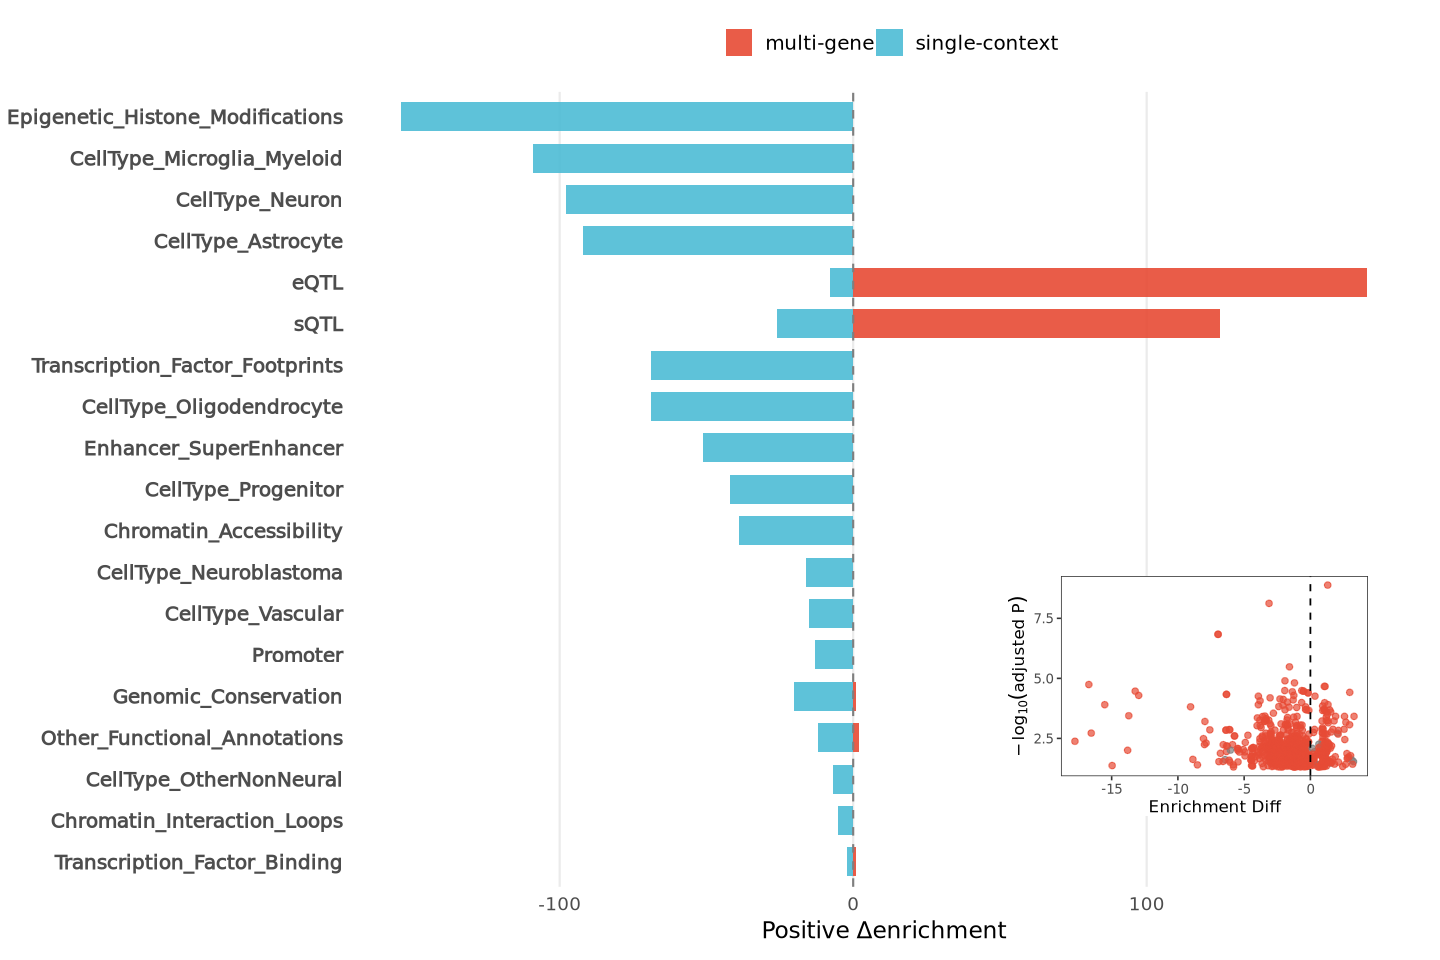

In [273]:
library(ggplot2)
library(dplyr)
library(grid)

# ---- prepare barplot data ----
sig_summary <- multigene_significant_results %>%
  mutate(Direction = ifelse(Enrichment_Diff > 0, "multi-gene", "single-context")) %>%
  count(Category, Direction) %>%
  group_by(Category) %>%
  mutate(Proportion = n / sum(n))

# ---- main barplot ----
p_bar <- ggplot(sig_summary, aes(x = reorder(Category, n),
                                 y = n * ifelse(Direction == "multi-gene", 1, -1),
                                 fill = Direction)) +
  geom_col(width = 0.7, alpha = 0.9) +
  coord_flip() +
  scale_fill_manual(values = c("multi-gene" = "#E64B35FF", 
                               "single-context" = "#4DBBD5FF")) +
  geom_hline(yintercept = 0, color = "gray50", linetype = "dashed", linewidth = 0.6) +
  theme_minimal(base_size = 14) +
  theme(
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    axis.text.y = element_text(size = 12, face = "bold"),
    axis.text.x = element_text(size = 11),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    legend.position = "top",
    legend.title = element_blank(),
    legend.text = element_text(size = 12),
    plot.margin = margin(10, 15, 10, 10)
  ) +
  labs(
    x = NULL,
    y = expression("Positive " * Delta * "enrichment"),
    # title = "Directional enrichment difference per category"
  )

# ---- volcano inset ----
p_volcano <- ggplot(significant_results, aes(x = Enrichment_Diff, 
                                             y = -log10(p_adjusted),
                                             color = Significance_Status)) +
  geom_point(size = 1.5, alpha = 0.7) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  scale_color_manual(values = c("Both" = "#E64B35FF", 
                                "Only_A" = "#4DBBD5FF", 
                                "Only_B" = "#00A087FF", 
                                "None" = "grey70")) +
  theme_bw(base_size = 10) +
  theme(
    legend.position = "none",
    panel.grid = element_blank(),
    plot.margin = margin(0,0,0,0)
  ) +
  labs(x = "Enrichment Diff", y = expression(-log[10](adjusted~P)))

# ---- combine (overlay volcano as inset) ----
library(cowplot)
options(repr.plot.width = 12, repr.plot.height =8)

final_plot <- ggdraw() +
  draw_plot(p_bar) +
  draw_plot(p_volcano, 
            x = 0.7, y = 0.15,    
            width = 0.25, height = 0.25)   

final_plot

In [275]:
ggsave("multigene_enrichment_bar_volcano.pdf", height = 5, width = 8)

#### Multi context to single context #####

In [248]:
enrichment_data_meta %>% filter(`Data Type` == 'multi_context') %>% pull(study) %>% unique 

# Filter eQTL data
bulk_eQTL <- enrichment_data_meta %>% filter(`Data Type` == 'eQTL')
snuc_eQTL <- enrichment_data_meta %>% filter(`Data Type` == 'snuc_eQTL')
eQTL_raw <- rbind(bulk_eQTL, snuc_eQTL)
multi_context_eQTL <- enrichment_data_meta %>% filter(`Data Type` == 'multi_context')

# Build a modalities dict to combine single context and multi gene results
modality_dict_multicontext <- c(
  "AC_DeJager_eQTL" = "AC_DeJager_eQTL_multicontext",
  "DLPFC_DeJager_eQTL" = "DLPFC_DeJager_eQTL_multicontext",
  "PCC_DeJager_eQTL" = "PCC_DeJager_eQTL_multicontext",
  "Ast_DeJager_eQTL" = "Ast_DeJager_eQTL_multicontext",
  "Inh_DeJager_eQTL" = "Inh_DeJager_eQTL_multicontext",
  "Exc_DeJager_eQTL" = "Exc_DeJager_eQTL_multicontext",
  "Mic_DeJager_eQTL" = "Mic_DeJager_eQTL_multicontext",
  "OPC_DeJager_eQTL" = "OPC_DeJager_eQTL_multicontext",
  "Oli_DeJager_eQTL" = "Oli_DeJager_eQTL_multicontext",
  "PCC_Kellis_eQTL" = "PCC_Kellis_eQTL_multicontext",
  "Ast_Kellis_eQTL" = "Ast_Kellis_eQTL_multicontext",
  "Inh_Kellis_eQTL" = "Inh_Kellis_eQTL_multicontext",
  "Exc_Kellis_eQTL" = "Exc_Kellis_eQTL_multicontext",
  "Mic_Kellis_eQTL" = "Mic_Kellis_eQTL_multicontext",
  "OPC_Kellis_eQTL" = "OPC_Kellis_eQTL_multicontext",
  "Oli_Kellis_eQTL" = "Oli_Kellis_eQTL_multicontext",
  "PCC_mega_eQTL" = "PCC_mega_eQTL_multicontext",
  "Ast_mega_eQTL" = "Ast_mega_eQTL_multicontext",
  "Inh_mega_eQTL" = "Inh_mega_eQTL_multicontext",
  "Exc_mega_eQTL" = "Exc_mega_eQTL_multicontext",
  "Mic_mega_eQTL" = "Mic_mega_eQTL_multicontext",
  "OPC_mega_eQTL" = "OPC_mega_eQTL_multicontext",
  "Oli_mega_eQTL" = "Oli_mega_eQTL_multicontext",
  "DLPFC_Bennett_pQTL" = "DLPFC_Bennett_pQTL_multicontext",
  "monocyte_ROSMAP_eQTL" = "monocyte_ROSMAP_eQTL_multicontext"

)

# Harmonize study names
eQTL <- eQTL_raw %>%
  filter(study %in% names(modality_dict_multicontext)) %>%
  mutate(study = recode(study, !!!modality_dict_multicontext))

multi_context_eQTL <- multi_context_eQTL %>%
  filter(study %in% as.character(modality_dict_multicontext))

# Compare enrichment across modalities
contexts <- as.character(modality_dict_multicontext)

[1] "AC_DeJager_eQTL_multicontext"      "Ast_DeJager_eQTL_multicontext"    
 [3] "Ast_Kellis_eQTL_multicontext"      "Ast_mega_eQTL_multicontext"       
 [5] "DLPFC_Bennett_pQTL_multicontext"   "DLPFC_DeJager_eQTL_multicontext"  
 [7] "Exc_DeJager_eQTL_multicontext"     "Exc_Kellis_eQTL_multicontext"     
 [9] "Exc_mega_eQTL_multicontext"        "Inh_DeJager_eQTL_multicontext"    
[11] "Inh_Kellis_eQTL_multicontext"      "Inh_mega_eQTL_multicontext"       
[13] "Mic_DeJager_eQTL_multicontext"     "Mic_Kellis_eQTL_multicontext"     
[15] "Mic_mega_eQTL_multicontext"        "OPC_DeJager_eQTL_multicontext"    
[17] "OPC_Kellis_eQTL_multicontext"      "OPC_mega_eQTL_multicontext"       
[19] "Oli_DeJager_eQTL_multicontext"     "Oli_Kellis_eQTL_multicontext"     
[21] "Oli_mega_eQTL_multicontext"        "PCC_DeJager_eQTL_multicontext"    
[23] "monocyte_ROSMAP_eQTL_multicontext"

In [249]:
combined_results <- map_dfr(contexts, function(context) { 
  significant_single <- eQTL %>% 
    filter(study == context, Enrichment_P_value < 0.05) %>% 
    select(Annotation) 
  significant_multi <- multi_context_eQTL %>% 
    filter(study == context, Enrichment_P_value < 0.05) %>% 
    select(Annotation) 
significant_annotations <- unique(c(significant_single$Annotation, significant_multi$Annotation))
  
  # Step 2: Merge datasets for significant annotations 
  merged_data <- inner_join( 
    eQTL %>% 
      filter(study == context, Annotation %in% significant_annotations) %>% 
      select(Annotation, Enrichment_single_context = Enrichment, Enrichment_SE_single_context = Enrichment_SE, Enrichment_P_value_single_context = Enrichment_P_value), 
    multi_context_eQTL %>% 
      filter(study == context, Annotation %in% significant_annotations) %>% 
      select(Annotation, Enrichment_multi_gene = Enrichment, Enrichment_SE_multi_gene = Enrichment_SE, Enrichment_P_value_multi_gene = Enrichment_P_value), 
    by = "Annotation" 
  ) %>% 
    filter(if_all(starts_with("Enrichment"), is.finite)) 
  
  # Step 3: Check if there are valid paired observations 
  if (nrow(merged_data) == 0) { 
    message("No valid paired observations for context: ", context) 
    return(NULL) 
  } 
  
  # Step 4: Perform Z-score test and calculate differences 
  results <- merged_data %>% 
    mutate( 
      Context = context, 
      Enrichment_Diff = Enrichment_multi_gene - Enrichment_single_context, 
      Enrichment_SE_combined = sqrt(Enrichment_SE_single_context^2 + Enrichment_SE_multi_gene^2), 
      z_score = Enrichment_Diff / Enrichment_SE_combined, 
      p_value = 2 * pnorm(-abs(z_score)), 
      p_adjusted = p.adjust(p_value, method = "fdr"), 
      Significance_Status = case_when( 
        Enrichment_P_value_single_context < 0.05 & Enrichment_P_value_multi_gene < 0.05 ~ "Both", 
        Enrichment_P_value_single_context < 0.05 ~ "Single Context Only", 
        Enrichment_P_value_multi_gene < 0.05 ~ "Multi-Gene Only" 
      ) 
    ) %>% 
    select(Context, Annotation, Enrichment_single_context, Enrichment_multi_gene, 
           Enrichment_Diff, Enrichment_SE_single_context, Enrichment_SE_multi_gene, 
           Enrichment_P_value_single_context, Enrichment_P_value_multi_gene, Significance_Status, 
           p_value, p_adjusted) 
  
  # Step 5: Filter significant results (FDR < 0.05) 
  significant <- results %>% 
    filter(!is.na(p_adjusted), p_adjusted < 0.05) %>% 
    mutate(Category = ifelse(grepl("\\|", Annotation), 
                             str_split(Annotation, "\\|", simplify = TRUE)[, 1], 
                             Annotation))  %>% distinct(Annotation, .keep_all = T)

  # if (nrow(significant) > 0) { 
  #   plot_data <- significant %>% 
  #     arrange(desc(abs(Enrichment_Diff))) %>% 
  #     slice_head(n = 30) %>% 
  #     mutate(Annotation = factor(Annotation, levels = Annotation)) 
    
  #   p <- ggplot(plot_data, aes(x = Enrichment_Diff, y = Annotation, fill = Category)) + 
  #     geom_bar(stat = "identity") + 
  #     geom_vline(xintercept = 0, linetype = "dashed") + 
  #     labs( 
  #       title = paste0("Top Enrichment Differences for ", context), 
  #       x = "Enrichment Difference (multi_context - single_context)", y = "" 
  #     ) + 
  #     theme_minimal() + 
  #     theme(plot.title = element_text(hjust = 0.5)) + 
  #     scale_fill_manual(values = all_colors) 
    
  #   out_path <- file.path('~/restricted/projectnb/xqtl/jaempawi/xqtl', 
  #                         'methods_compare/multi_context/', paste0(context, '_multigene_single_enrichment_plot_combined.pdf'))    #FIXME
  #   dir.create(dirname(out_path), recursive = TRUE, showWarnings = FALSE) 
  #   ggsave(out_path, plot = p, height = 10, width = 14, limitsize = FALSE) 
  # } 
  
  results 
})

# Filter for significant results and plot summary
significant_results <- combined_results %>%
  filter(!is.na(p_adjusted), p_adjusted < 0.05) %>%
  mutate(Category = str_extract(Annotation, "^[^|]+"))

cat("Number of significantly different annotations (FDR < 0.05):", nrow(significant_results), "\n")

No valid paired observations for context: PCC_Kellis_eQTL_multicontext

No valid paired observations for context: PCC_mega_eQTL_multicontext

No valid paired observations for context: DLPFC_Bennett_pQTL_multicontext



Number of significantly different annotations (FDR < 0.05): 874 


In [297]:
significant_results %>% head

,Context,Annotation,Enrichment_single_context,Enrichment_multi_gene,Enrichment_Diff,Enrichment_SE_single_context,Enrichment_SE_multi_gene,Enrichment_P_value_single_context,Enrichment_P_value_multi_gene,Significance_Status,p_value,p_adjusted,Category
,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
1,AC_DeJager_eQTL_multicontext,eQTL|formatted_output_GTEx_brain_caudate_SNP_significant.bed,8.018848,6.279597,-1.7392509,0.48148610,0.31924515,0,3.887053e-86,Both,2.607266e-03,2.336701e-02,eQTL
2,AC_DeJager_eQTL_multicontext,CellType_Neuron|BI.H9_Derived_Neuron_Cultured_Cells.H3K4me3.113.narrowPeak.lifted.bed,8.730508,7.136387,-1.5941203,0.37431697,0.29663642,0,6.935560e-128,Both,8.446298e-04,1.253747e-02,CellType_Neuron
3,AC_DeJager_eQTL_multicontext,CellType_Microglia_Myeloid|PU1_TSS_H3K27ac,11.327100,8.968738,-2.3583624,0.55727786,0.43907466,0,9.732114e-93,Both,8.869584e-04,1.276683e-02,CellType_Microglia_Myeloid
4,AC_DeJager_eQTL_multicontext,Transcription_Factor_Footprints|ENCSR910OQF.spinal_cord_hint_20-footprint.bed,3.556767,2.902740,-0.6540274,0.09424092,0.08072819,0,3.940992e-283,Both,1.359946e-07,3.229871e-05,Transcription_Factor_Footprints
5,AC_DeJager_eQTL_multicontext,CellType_Oligodendrocyte|Olig2_optimal_peak.H3K4me3,10.414798,8.131852,-2.2829465,0.45932125,0.35833750,0,5.220168e-114,Both,8.899629e-05,2.351229e-03,CellType_Oligodendrocyte
6,AC_DeJager_eQTL_multicontext,Genomic_Conservation|Intron_UCSC.flanking.500,9.426059,7.322148,-2.1039105,0.51610422,0.39896776,0,3.139226e-75,Both,1.258814e-03,1.617257e-02,Genomic_Conservation


### barplot with volcano

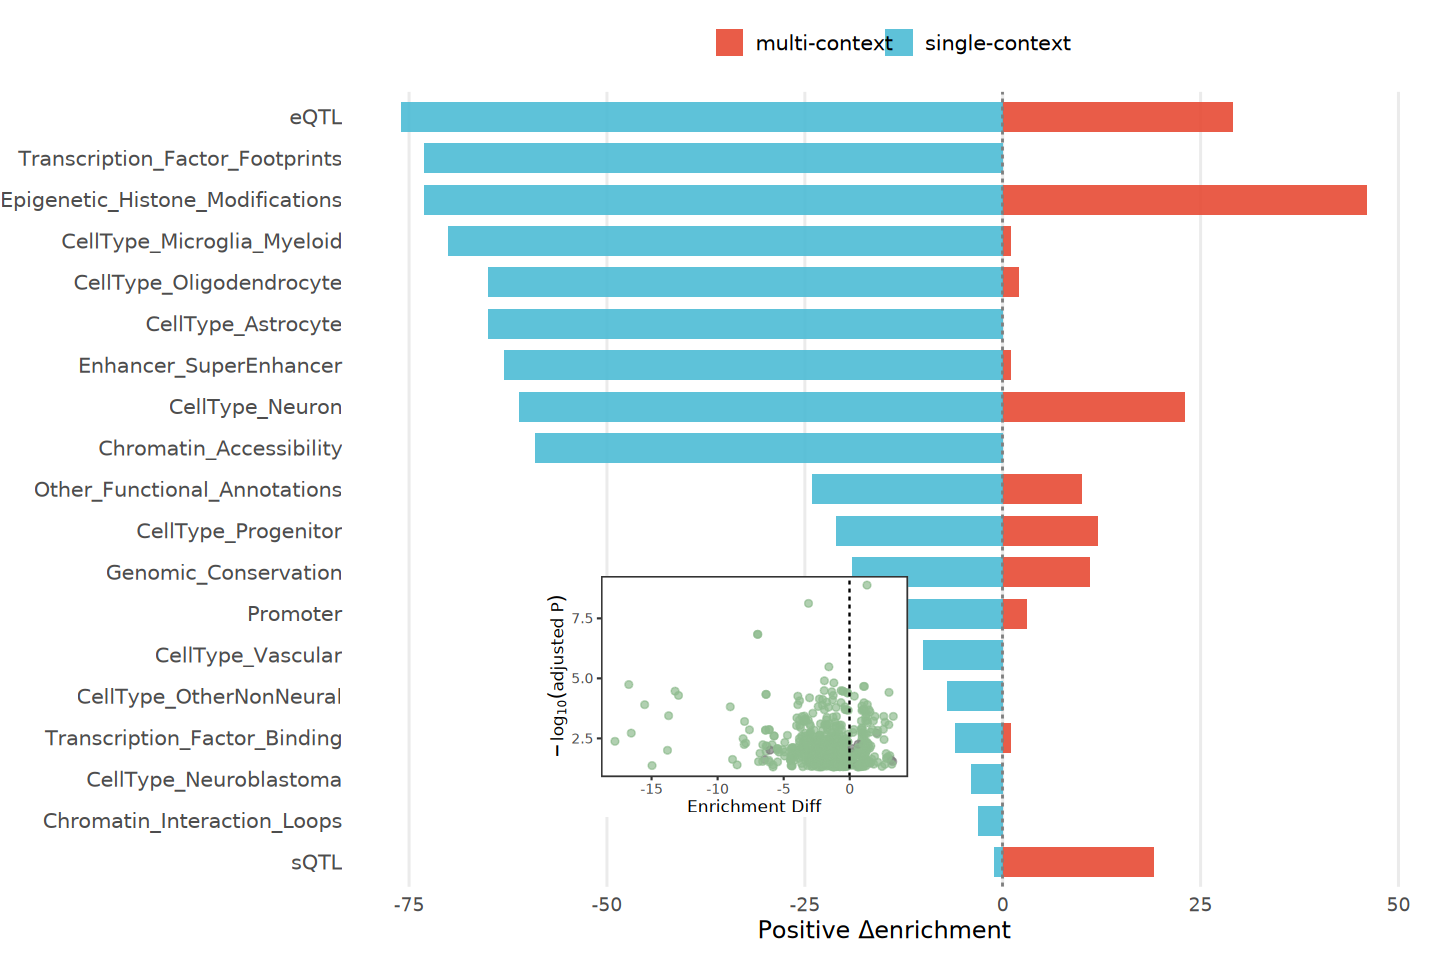

In [338]:
library(ggplot2)
library(dplyr)
library(grid)

# ---- prepare barplot data ----
sig_summary <- significant_results %>%
  mutate(Direction = ifelse(Enrichment_Diff > 0, "multi-context", "single-context")) %>%
  count(Category, Direction) %>%
  group_by(Category) %>%
  mutate(Proportion = n / sum(n))


order_df <- sig_summary %>%
  filter(Direction == "single-context") %>%
  arrange(n) %>%            # 
  pull(Category)

sig_summary$Category_ordered <- factor(sig_summary$Category, 
                                       levels = order_df)

# ---- main barplot ----
p_bar <- ggplot(sig_summary, aes(x = Category_ordered,
                                 y = n * ifelse(Direction == "multi-context", 1, -1),
                                 fill = Direction)) +
  geom_col(width = 0.7, alpha = 0.9) +
  coord_flip() +
  scale_fill_manual(values = c("multi-context" = "#E64B35FF", 
                               "single-context" = "#4DBBD5FF")) +
  geom_hline(yintercept = 0, color = "gray50", linetype = "dashed", linewidth = 0.6) +
  theme_minimal(base_size = 14) +
  theme(
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    axis.text.y = element_text(size = 12, face = "bold"),
    axis.text.x = element_text(size = 11),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    legend.position = "top",
    legend.title = element_blank(),
    legend.text = element_text(size = 12),
    plot.margin = margin(10, 15, 10, 10)
  ) +
  labs(
    x = NULL,
    y = expression("Positive " * Delta * "enrichment"),
    # title = "Directional enrichment difference per category"
  )

# ---- volcano inset ----
p_volcano <- ggplot(significant_results, aes(x = Enrichment_Diff, 
                                             y = -log10(p_adjusted),
                                             color = Significance_Status)) +
  geom_point(size = 1.5, alpha = 0.7) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  scale_color_manual(values = c("Both" = "#8FBC8F", 
                                "Only_A" = "#E64B35FF", 
                                "Only_B" = "#4DBBD5FF", 
                                "None" = "grey70")) +
  theme_bw(base_size = 10) +
  theme(
    legend.position = "none",
    panel.grid = element_blank(),
    plot.margin = margin(0,0,0,0)
  ) +
  labs(x = "Enrichment Diff", y = expression(-log[10](adjusted~P)))

# ---- combine (overlay volcano as inset) ----
library(cowplot)
options(repr.plot.width = 12, repr.plot.height =8)

final_plot <- ggdraw() +
  draw_plot(p_bar) +
  draw_plot(p_volcano, 
            x = 0.38, y = 0.15,    
            width = 0.25, height = 0.25)   

final_plot

In [339]:
ggsave("Figure2D.multicontext_enrichment_bar_volcano.pdf", height = 5, width = 8)

### barplot with super category facet

In [324]:
sig_summary <- significant_results%>%
  mutate(Direction = ifelse(Enrichment_Diff > 0, "multi-context", "single-context")) %>%
  count(Category, Direction) %>%
  group_by(Category) %>%
  mutate(Proportion = n / sum(n)) %>% 
  mutate(
    Super_category = case_when(
      Category %in% c(
        "CellType_Neuron", "CellType_Astrocyte", "CellType_Microglia_Myeloid",
        "CellType_Oligodendrocyte", "CellType_Progenitor",
        "CellType_Neuroblastoma", "CellType_OtherNonNeural",
        "CellType_Vascular"
      ) ~ "CellType_specific",
      Category %in% c("eQTL", "sQTL") ~ "Molecular_QTL",
      Category %in% c(
        "Epigenetic_Histone_Modifications",
        "Chromatin_Accessibility",
        "Chromatin_Interaction_Loops",
        "Enhancer_SuperEnhancer",
        "Promoter",
        "Transcription_Factor_Binding",
        "Transcription_Factor_Footprints"
      ) ~ "Epigenetic_Regulation",
      Category %in% c("Genomic_Conservation") ~ "Conservation",
      Category %in% c("Miscellaneous", "Other_Functional_Annotations") ~ "Other",
      TRUE ~ "Other"
    ))
 

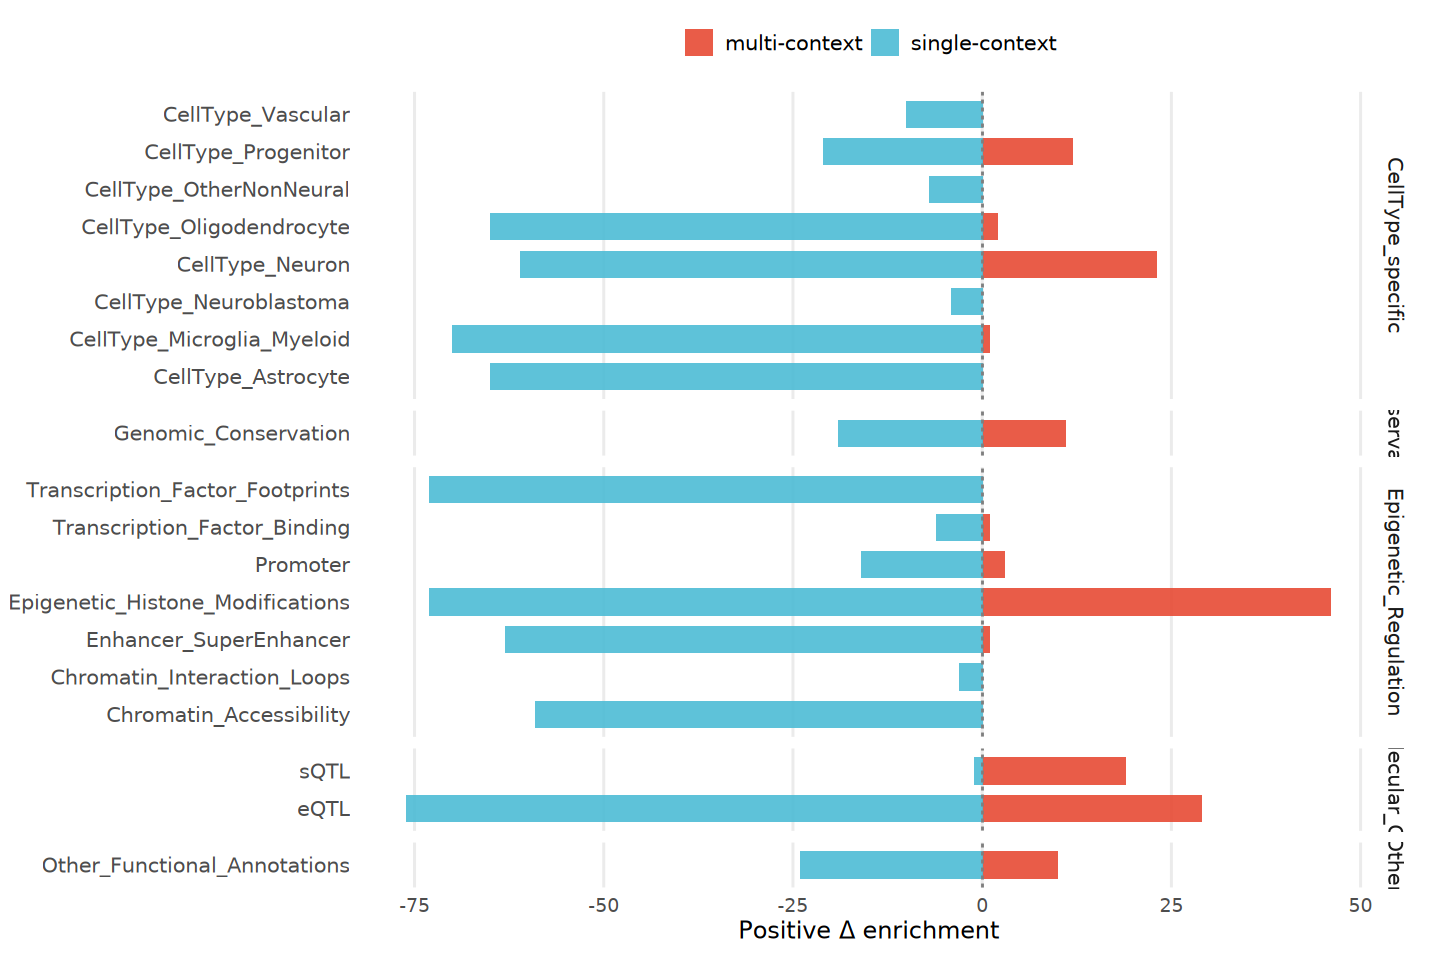

In [326]:
ggplot(sig_summary, aes(
    x = Category,
    y = n * ifelse(Direction == "multi-context", 1, -1),
    fill = Direction
)) +
  geom_col(width = 0.7, alpha = 0.9) +
  coord_flip() +
  scale_fill_manual(values = c(
    "multi-context" = "#E64B35FF",
    "single-context" = "#4DBBD5FF"
  )) +
  geom_hline(yintercept = 0, color = "gray50", linetype = "dashed", linewidth = 0.6) +
  facet_grid(
    Super_category ~ .,
    scales = "free_y",
    space  = "free_y"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    panel.grid.major.y = element_blank(),
    panel.grid.minor   = element_blank(),
    axis.text.y        = element_text(size = 12, face = "bold"),
    axis.text.x        = element_text(size = 11),
    legend.position    = "top",
    legend.title       = element_blank(),
    legend.text        = element_text(size = 12),
    plot.margin        = margin(10, 15, 10, 10),
    strip.text.y       = element_text(size = 12, face = "bold")
  ) +
  labs(
    x = NULL,
    y = expression("Positive " * Delta * " enrichment")
  )

### barplot with super category

In [328]:
sig_summary <- significant_results %>%
  mutate(
    Super_category = case_when(
      Category %in% c(
        "CellType_Neuron", "CellType_Astrocyte", "CellType_Microglia_Myeloid",
        "CellType_Oligodendrocyte", "CellType_Progenitor",
        "CellType_Neuroblastoma", "CellType_OtherNonNeural",
        "CellType_Vascular"
      ) ~ "CellType_specific",
      Category %in% c("eQTL", "sQTL") ~ "Molecular_QTL",
      Category %in% c(
        "Epigenetic_Histone_Modifications",
        "Chromatin_Accessibility",
        "Chromatin_Interaction_Loops",
        "Enhancer_SuperEnhancer",
        "Promoter",
        "Transcription_Factor_Binding",
        "Transcription_Factor_Footprints"
      ) ~ "Epigenetic_Regulation",
      Category %in% c("Genomic_Conservation") ~ "Conservation",
      Category %in% c("Miscellaneous", "Other_Functional_Annotations") ~ "Other",
      TRUE ~ "Other"
    ))%>%
  mutate(Direction = ifelse(Enrichment_Diff > 0, "multi-context", "single-context")) %>%
  count(Super_category, Direction) %>%
  group_by(Super_category) %>%
  mutate(Proportion = n / sum(n)) %>% mutate(Category = Super_category)

order_df <- sig_summary %>%
  filter(Direction == "single-context") %>%
  arrange(n) %>%            # 
  pull(Category)

sig_summary$Category_ordered <- factor(sig_summary$Category, 
                                       levels = order_df)

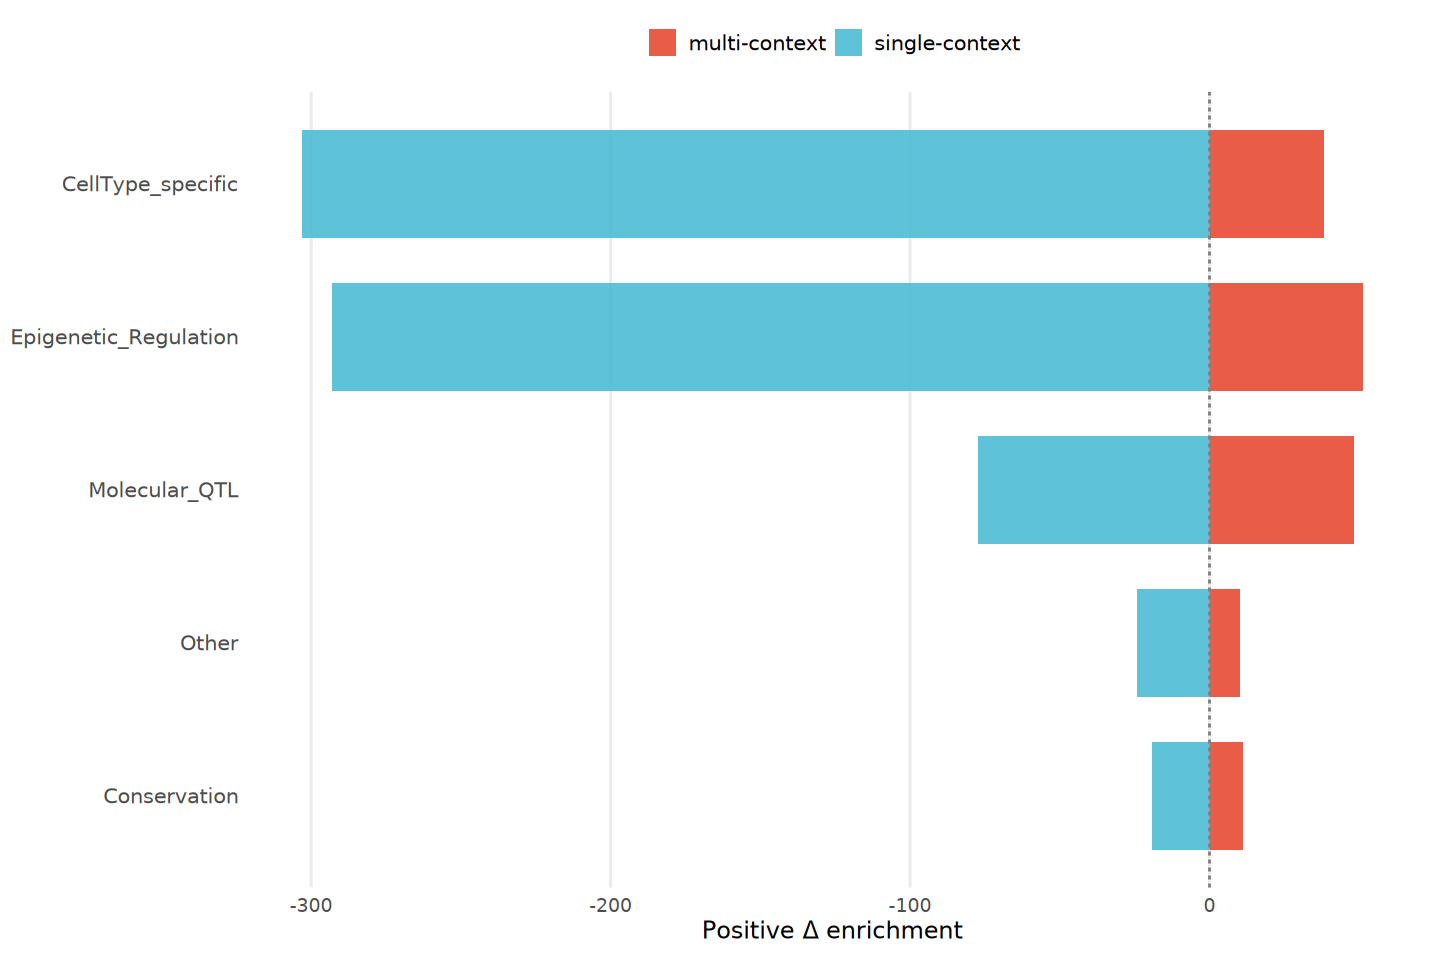

In [329]:
ggplot(sig_summary, aes(
    x = Category_ordered,
    y = n * ifelse(Direction == "multi-context", 1, -1),
    fill = Direction
)) +
  geom_col(width = 0.7, alpha = 0.9) +
  coord_flip() +
  scale_fill_manual(values = c(
    "multi-context" = "#E64B35FF",
    "single-context" = "#4DBBD5FF"
  )) +
  geom_hline(yintercept = 0, color = "gray50", linetype = "dashed", linewidth = 0.6) +
  # facet_grid(
  #   Super_category ~ .,
  #   scales = "free_y",
  #   space  = "free_y"
  # ) +
  theme_minimal(base_size = 14) +
  theme(
    panel.grid.major.y = element_blank(),
    panel.grid.minor   = element_blank(),
    axis.text.y        = element_text(size = 12, face = "bold"),
    axis.text.x        = element_text(size = 11),
    legend.position    = "top",
    legend.title       = element_blank(),
    legend.text        = element_text(size = 12),
    plot.margin        = margin(10, 15, 10, 10),
    strip.text.y       = element_text(size = 12, face = "bold")
  ) +
  labs(
    x = NULL,
    y = expression("Positive " * Delta * " enrichment")
  )